In [1]:
import pandas as pd

In [2]:
r = pd.read_csv('rides.csv', skipinitialspace=True)

In [3]:
r['Start Date']

0         2023-04-22 09:01:03
1         2023-04-22 09:01:07
2         2023-04-22 09:04:27
3         2023-04-22 09:06:34
4         2023-04-22 09:09:27
                 ...         
102250    2023-07-31 23:45:06
102251    2023-07-31 23:46:01
102252    2023-07-31 23:48:04
102253    2023-07-31 23:51:41
102254    2023-07-31 23:57:01
Name: Start Date, Length: 102255, dtype: object

In [4]:
set(r['Start Date'].apply(lambda x: len(x)))

{19}

In [5]:
r['Start Date'] = r['Start Date'].apply(lambda x: pd.to_datetime(x))

In [6]:
r['Days'] = r['Start Date'].apply(lambda x: x.day)

In [7]:
r['Month'] = r['Start Date'].apply(lambda x: x.month)

In [8]:
def time_day(x):
    if 5 <= x <= 12:
        return 'Morning'
    elif 12 < x <= 18:
        return 'Day'
    elif 18 < x <= 22:
        return 'Evening'
    return 'Night'

In [9]:
r['time_of_day'] = r['Start Date'].apply(lambda x: time_day(x.hour))

In [10]:
r = r[r['End Date'] != 'NaT']

In [11]:
r['End Date'] = r['End Date'].apply(lambda x: pd.to_datetime(x))

In [12]:
r['Duration'] = r['End Date'] - r['Start Date']

In [13]:
r

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Days,Month,time_of_day,Duration
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0,22,4,Morning,0 days 00:23:42
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0,22,4,Morning,0 days 00:28:25
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0,22,4,Morning,0 days 00:38:19
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0,22,4,Morning,0 days 00:31:49
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0,22,4,Morning,0 days 00:30:40
...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0,31,7,Night,0 days 00:21:49
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0,31,7,Night,0 days 00:39:34
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0,31,7,Night,0 days 00:21:17
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0,31,7,Night,0 days 00:46:23


In [14]:
def formating(x):
    s = x.seconds
    hour = x.seconds // 3600
    minutes = (x.seconds - x.seconds // 3600) // 60
    sec = (x.seconds - x.seconds // 3600) % 60
    a = []
    for i in [hour, minutes, sec]:
        a.append(str(i))
    return a

r['Duration'] = r['Duration'].apply(lambda x: ' '.join(formating(x)))

In [15]:
r['stupid_duration'] = r['End Date'] - r['Start Date']
r['stupid_duration'] = r['stupid_duration'].apply(lambda x: x.seconds)

In [16]:
r = r.dropna()

In [17]:
r['Average_speed'] = r['Distance'] / r['stupid_duration']

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\4245932514.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['Average_speed'] = r['Distance'] / r['stupid_duration']


In [18]:
r['Average_speed'] = r['Average_speed'].apply(lambda x: round(x * 3.6, 1))

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\1969452519.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['Average_speed'] = r['Average_speed'].apply(lambda x: round(x * 3.6, 1))


In [19]:
def time_of_the_year(x):
    d = {
        1: 'Winter',
        2: 'Winter',
        3: 'Spring',
        4: 'Spring',
        5: 'Spring',
        6: 'Summer',
        7: 'Summer',
        8: 'Summer',
        9: 'Autumn',
        10: 'Autumn',
        11: 'Autumn',
        12: 'Winter',
    }
    return d[x]

In [20]:
r['Month'] = r['Month'].apply(time_of_the_year)

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\2370695112.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['Month'] = r['Month'].apply(time_of_the_year)


In [21]:
dw = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [22]:
r['Days'] = r['Start Date'].apply(lambda x: dw[x.day_of_week])

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\878048366.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['Days'] = r['Start Date'].apply(lambda x: dw[x.day_of_week])


C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\609139594.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Days', data=r, palette='Set2')


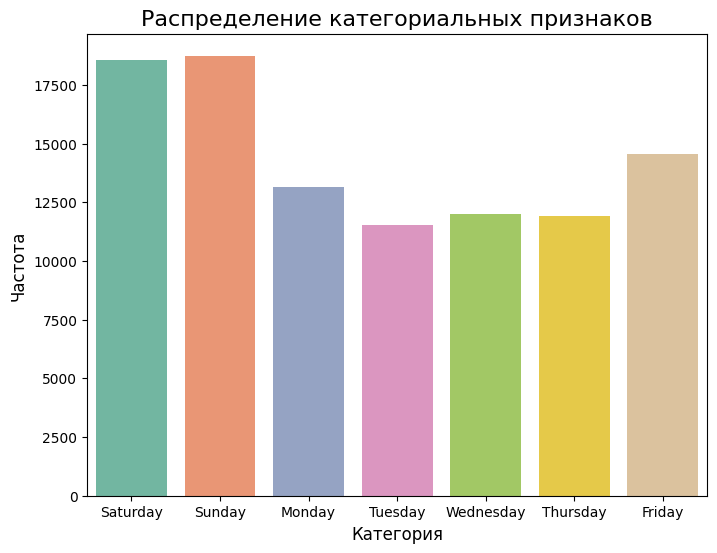

In [24]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8, 6))
# sns.countplot(x='Days', data=r, palette='Set2')

# plt.title('Распределение категориальных признаков', fontsize=16)
# plt.xlabel('Категория', fontsize=12)
# plt.ylabel('Частота', fontsize=12)

# plt.show()


In [25]:
r = r[r['Distance'] < 10000]
r = r[r['Distance'] > 10]

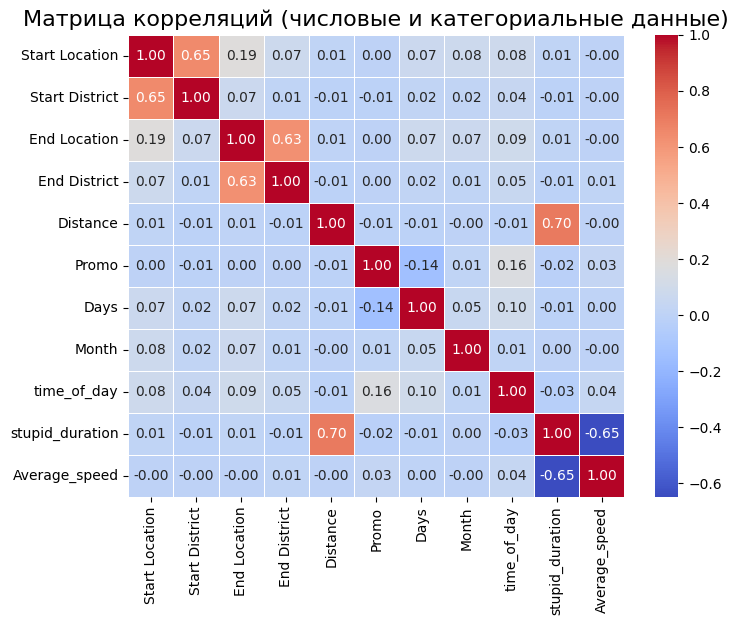

In [29]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.stats import pearsonr, spearmanr, chi2_contingency

# df = r.copy()

# # Функция для вычисления корреляции между столбцами
# def calc_correlation(col1, col2):
#     if col1.dtype == 'object' and col2.dtype == 'object':
#         contingency_table = pd.crosstab(col1, col2)
#         chi2, p, dof, ex = chi2_contingency(contingency_table)
#         cramer_v = np.sqrt(chi2 / (col1.shape[0] * (min(contingency_table.shape) - 1)))
#         return cramer_v
#     elif col1.dtype != 'object' and col2.dtype != 'object':  # Числовые-Числовые
#         corr, _ = pearsonr(col1, col2)
#         return corr
#     else:  # Числовые-Категориальные
#         # Применяем тест хи-квадрат или ранговую корреляцию
#         if col1.dtype != 'object':  # Числовой столбец в первом месте
#             corr, _ = spearmanr(col1, col2)
#         else:  # Числовой столбец во втором месте
#             corr, _ = spearmanr(col2, col1)
#         return corr

# # Создаем пустую матрицу для хранения корреляций
# columns = list(df.columns)
# columns.remove('Start Date')
# columns.remove('End Date')
# columns.remove('Id')
# columns.remove('Duration')
# correlation_matrix = pd.DataFrame(index=columns, columns=columns)

# # Заполняем матрицу корреляции
# for col1 in columns:
#     for col2 in columns:
#         correlation_matrix.loc[col1, col2] = calc_correlation(df[col1], df[col2])

# # Преобразуем все значения в числовой формат для дальнейшего отображения
# correlation_matrix = correlation_matrix.astype(float)

# # Строим тепловую карту для отображения матрицы корреляций
# plt.figure(figsize=(8, 6))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# plt.title('Матрица корреляций (числовые и категориальные данные)', fontsize=16)
# plt.show()


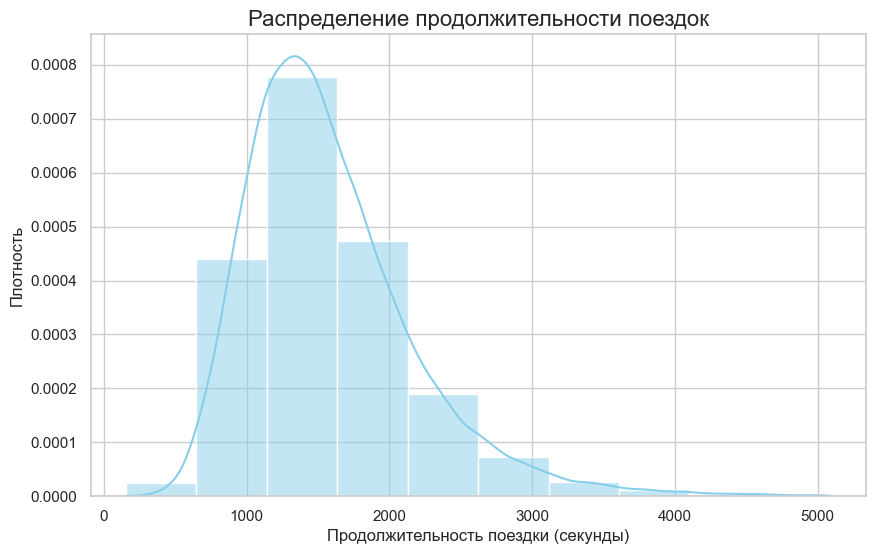

In [30]:
# sns.set(style="whitegrid")
# plt.figure(figsize=(10, 6))
# sns.histplot(list(r['stupid_duration']), kde=True, bins=10, color='skyblue', stat='density')

# # Настроим подписи и заголовок
# plt.title('Распределение продолжительности поездок', fontsize=16)
# plt.xlabel('Продолжительность поездки (секунды)', fontsize=12)
# plt.ylabel('Плотность', fontsize=12)

# # Покажем график
# plt.show()


In [32]:
w = pd.read_csv('weather.csv')

In [35]:
w['Precipitation Total'] = w['Precipitation Total'].fillna(method='ffill')
w['Wind Speed'] = w['Wind Speed'].fillna(method='ffill')
w['Cloud Cover Total'] = w['Cloud Cover Total'].fillna(method='ffill')
w['Sunshine Duration'] = w['Sunshine Duration'].fillna(method='ffill')

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\1301029932.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  w['Precipitation Total'] = w['Precipitation Total'].fillna(method='ffill')
C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\1301029932.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  w['Wind Speed'] = w['Wind Speed'].fillna(method='ffill')
C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\1301029932.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  w['Cloud Cover Total'] = w['Cloud Cover Total'].fillna(method='ffill')
C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\1301029932.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() 

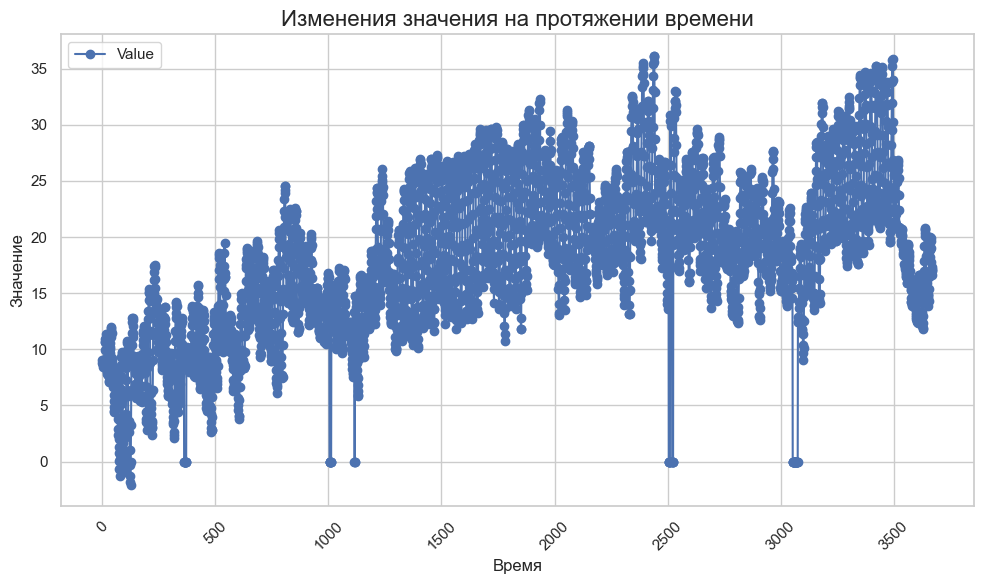

In [36]:
# plt.figure(figsize=(10, 6))
# plt.plot([i for i in range(len(w))], list(w.fillna(0)['Temperature'].astype('float')), marker='o', linestyle='-', color='b', label='Value')

# # Настройка графика
# plt.title('Изменения значения на протяжении времени', fontsize=16)
# plt.xlabel('Время', fontsize=12)
# plt.ylabel('Значение', fontsize=12)
# plt.xticks(rotation=45)  # Повернем метки времени для удобства
# plt.grid(True)
# plt.legend()

# # Покажем график
# plt.tight_layout()
# plt.show()

In [38]:
w['Time of the year'] = w['Datetime'].apply(lambda x: time_of_the_year(pd.to_datetime(x).month))

In [39]:
test_df = w[w['Temperature'].isna()]  # Строки, где Temperature == NaN
train_df = w[w['Temperature'].notna()]  # Строки, где Temperature не NaN

,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year
1,2023-04-01T00:00:00,8.740245,0.1,48.6,21.638964,90,0,Spring
2,2023-04-01T01:00:00,9.040245,0.2,55.44,22.493519,74,0,Spring
3,2023-04-01T02:00:00,8.880245,0.3,55.8,22.26477,72,0,Spring
4,2023-04-01T03:00:00,8.690246,0.3,55.44,21.94524,77,0,Spring
5,2023-04-01T04:00:00,8.630245,0.3,48.96,22.42427,78,0,Spring
...,...,...,...,...,...,...,...,...
3668,2023-08-31T19:00:00,16.940245,0,10.799999,1.08,89,1.4999998,Summer
3669,2023-08-31T20:00:00,16.630245,0,11.159999,1.1384199,83,0,Summer
3670,2023-08-31T21:00:00,17.080246,0.1,17.64,3.396233,82,0,Summer
3671,2023-08-31T22:00:00,17.180244,0,21.599998,7.2359104,80,0,Summer


In [40]:
len(test_df)

55

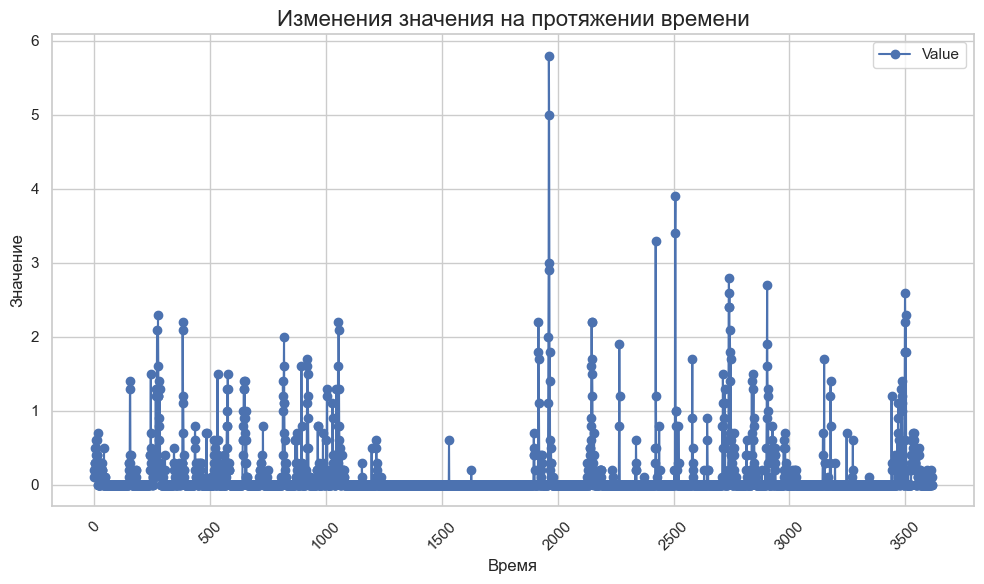

In [41]:
# plt.figure(figsize=(10, 6))
# plt.plot([i for i in range(len(train_df))], list(train_df.fillna(7)['Precipitation Total'].astype('float')), marker='o', linestyle='-', color='b', label='Value')

# # Настройка графика
# plt.title('Изменения значения на протяжении времени', fontsize=16)
# plt.xlabel('Время', fontsize=12)
# plt.ylabel('Значение', fontsize=12)
# plt.xticks(rotation=45)  # Повернем метки времени для удобства
# plt.grid(True)
# plt.legend()

# # Покажем график
# plt.tight_layout()
# plt.show()

In [42]:
train_df['Precipitation Total'] = train_df['Precipitation Total'].astype('float')
train_df = train_df[train_df['Precipitation Total'] < 3]

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\1466324480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Precipitation Total'] = train_df['Precipitation Total'].astype('float')


In [44]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [45]:
df_ohe = pd.get_dummies(train_df, columns=['Time of the year'], prefix='Category')

In [46]:
df_ohe['Category_Summer'] = df_ohe['Category_Summer'].astype('float')
df_ohe['Category_Spring'] = df_ohe['Category_Spring'].astype('float')

In [47]:
df_ohe = df_ohe.drop(columns=['Datetime'])

In [48]:
df_ohe.isna().sum()

Temperature            0
Precipitation Total    0
Wind Gust              0
Wind Speed             0
Cloud Cover Total      0
Sunshine Duration      0
Category_Spring        0
Category_Summer        0
dtype: int64

In [49]:
X = df_ohe[['Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration', 'Category_Spring', 'Category_Summer']]  # Признаки (вектора)
y = df_ohe['Temperature']  # Целевой признак (то, что нужно предсказать)

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создаем модель линейной регрессии
model = LinearRegression()

# Обучаем модель
model.fit(X_train, y_train)

# Делаем предсказания на тестовых данных
y_pred = model.predict(X_test)

# Оценим качество модели (с помощью MSE - Среднеквадратичной ошибки)
mse = mean_squared_error(y_test, y_pred)

# Выводим результаты
print(f"Среднеквадратичная ошибка: {mse}")

Среднеквадратичная ошибка: 17.75774037279789


In [50]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)  # Степень полинома
X_poly = poly.fit_transform(X)

# Разделяем данные на обучающие и тестовые
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Линейная регрессия для полиномиальных признаков
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Прогнозирование
y_pred_poly = poly_model.predict(X_test_poly)

# Оценка модели
mse_poly = mean_squared_error(y_test, y_pred_poly)
print(f"Среднеквадратичная ошибка (MSE) для Polynomial Regression: {mse_poly}")

Среднеквадратичная ошибка (MSE) для Polynomial Regression: 16.556552704752406


In [51]:
from sklearn.svm import SVR

# Поддерживающая векторная машина (SVM)
svm_model = SVR(kernel='linear')  # Можно использовать различные ядра
svm_model.fit(X_train, y_train)

# Прогнозирование
y_pred_svm = svm_model.predict(X_test)

# Оценка модели
mse_svm = mean_squared_error(y_test, y_pred_svm)
print(f"Среднеквадратичная ошибка (MSE) для SVM: {mse_svm}")

Среднеквадратичная ошибка (MSE) для SVM: 18.406303605933136


In [52]:
from sklearn.ensemble import GradientBoostingRegressor

# Градиентный бустинг
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Прогнозирование
y_pred_gb = gb_model.predict(X_test)

# Оценка модели
mse_gb = mean_squared_error(y_test, y_pred_gb)
print(f"Среднеквадратичная ошибка (MSE) для Gradient Boosting: {mse_gb}")

Среднеквадратичная ошибка (MSE) для Gradient Boosting: 15.585215264136334


In [53]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

model = CatBoostRegressor(iterations=10000,  # Максимальное количество итераций
                          learning_rate=0.1,  # Коэффициент обучения
                          depth=6,  # Глубина деревьев
                          cat_features=[],  # Список категориальных признаков (если есть)
                          verbose=200,  # Печать прогресса
                          early_stopping_rounds=50)  # Останавливаем обучение, если ошибка не улучшается в течение 50 раундов

# Обучение модели с валидацией на валидационном наборе
model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# Прогнозирование
y_pred = model.predict(X_test)

# Оценка модели
mse = mean_squared_error(y_test, y_pred)
print(f"Среднеквадратичная ошибка (MSE) на тестовых данных: {mse}")

0:	learn: 6.4177160	test: 6.5217056	best: 6.5217056 (0)	total: 164ms	remaining: 27m 15s
200:	learn: 3.2171956	test: 3.8320557	best: 3.8290882 (192)	total: 466ms	remaining: 22.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3.822270472
bestIteration = 293

Shrink model to first 294 iterations.
Среднеквадратичная ошибка (MSE) на тестовых данных: 14.609751665101168


In [54]:
df_ohe1 = pd.get_dummies(test_df, columns=['Time of the year'], prefix='Category')
df_ohe1['Category_Summer'] = df_ohe1['Category_Summer'].astype('float')
df_ohe1['Category_Spring'] = df_ohe1['Category_Spring'].astype('float')
y_pred1 = model.predict(df_ohe1[['Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration', 'Category_Spring', 'Category_Summer']])

In [55]:
test_df['Temperature'] = y_pred1

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\1601399170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Temperature'] = y_pred1


In [56]:
test_df

,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year
363,2023-04-16T02:00:00,9.200621,0.3,13.32,3.671294,100,0,Spring
364,2023-04-16T03:00:00,9.708689,0.4,13.32,4.452954,98,0,Spring
365,2023-04-16T04:00:00,8.903787,0.4,13.32,4.802999,100,0,Spring
366,2023-04-16T05:00:00,8.830492,0.3,13.679999,4.379589,100,0,Spring
367,2023-04-16T06:00:00,8.999679,0.2,14.4,5.0528407,100,0,Spring
368,2023-04-16T07:00:00,8.504952,0.3,15.4800005,6.379216,100,0,Spring
369,2023-04-16T08:00:00,9.763513,0.2,19.08,9.957108,100,0,Spring
370,2023-04-16T09:00:00,10.839634,0.2,24.48,10.383987,100,0,Spring
371,2023-04-16T10:00:00,11.493023,0.2,24.48,7.7043357,100,0,Spring
372,2023-04-16T11:00:00,12.649885,0.3,24.84,8.534353,91,4.8484864,Spring


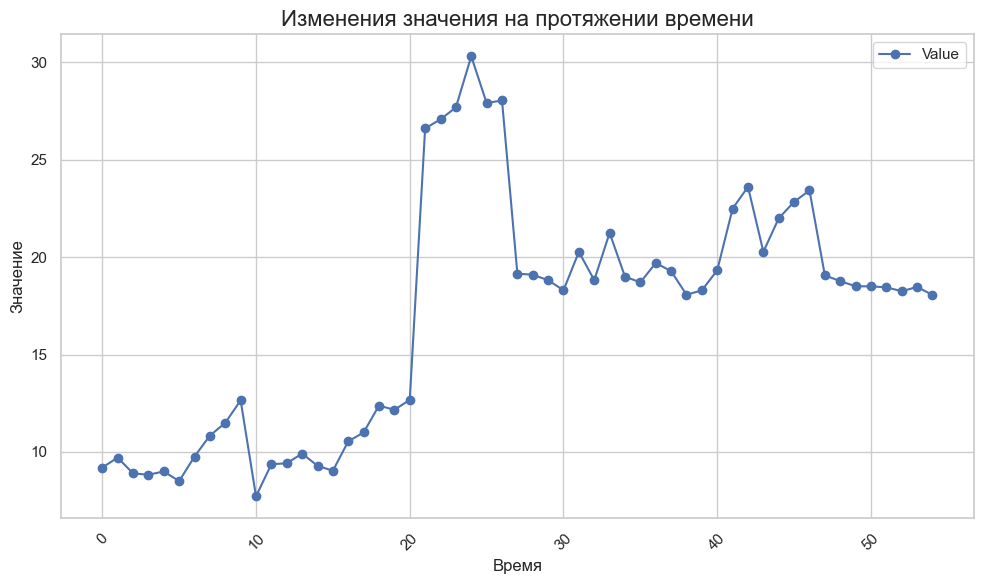

In [57]:
# plt.figure(figsize=(10, 6))
# plt.plot([i for i in range(len(test_df))], list(test_df['Temperature'].astype('float')), marker='o', linestyle='-', color='b', label='Value')

# # Настройка графика
# plt.title('Изменения значения на протяжении времени', fontsize=16)
# plt.xlabel('Время', fontsize=12)
# plt.ylabel('Значение', fontsize=12)
# plt.xticks(rotation=45)  # Повернем метки времени для удобства
# plt.grid(True)
# plt.legend()

# # Покажем график
# plt.tight_layout()
# plt.show()

In [58]:
test_df['Datetime'] = test_df['Datetime'].apply(lambda x: pd.to_datetime(x))
train_df['Datetime'] = train_df['Datetime'].apply(lambda x: pd.to_datetime(x))

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3117978878.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Datetime'] = test_df['Datetime'].apply(lambda x: pd.to_datetime(x))
C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3117978878.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Datetime'] = train_df['Datetime'].apply(lambda x: pd.to_datetime(x))


In [59]:
merged_df = pd.concat([train_df, test_df])  # Можно выбрать тип слияния: 'inner', 'outer', 'left', 'right'
w1 = merged_df.copy()

In [60]:
sorted(set(w1['Datetime']))

[Timestamp('2023-04-01 00:00:00'),
 Timestamp('2023-04-01 01:00:00'),
 Timestamp('2023-04-01 02:00:00'),
 Timestamp('2023-04-01 03:00:00'),
 Timestamp('2023-04-01 04:00:00'),
 Timestamp('2023-04-01 05:00:00'),
 Timestamp('2023-04-01 06:00:00'),
 Timestamp('2023-04-01 07:00:00'),
 Timestamp('2023-04-01 08:00:00'),
 Timestamp('2023-04-01 09:00:00'),
 Timestamp('2023-04-01 10:00:00'),
 Timestamp('2023-04-01 11:00:00'),
 Timestamp('2023-04-01 12:00:00'),
 Timestamp('2023-04-01 13:00:00'),
 Timestamp('2023-04-01 14:00:00'),
 Timestamp('2023-04-01 15:00:00'),
 Timestamp('2023-04-01 16:00:00'),
 Timestamp('2023-04-01 17:00:00'),
 Timestamp('2023-04-01 18:00:00'),
 Timestamp('2023-04-01 19:00:00'),
 Timestamp('2023-04-01 20:00:00'),
 Timestamp('2023-04-01 21:00:00'),
 Timestamp('2023-04-01 22:00:00'),
 Timestamp('2023-04-01 23:00:00'),
 Timestamp('2023-04-02 00:00:00'),
 Timestamp('2023-04-02 01:00:00'),
 Timestamp('2023-04-02 02:00:00'),
 Timestamp('2023-04-02 03:00:00'),
 Timestamp('2023-04-

In [61]:
ti = w1['Datetime'].min()
lim = w1['Datetime'].max()
while ti != lim:
    ti += pd.Timedelta(1, "h")
    if ti not in w1['Datetime'].to_list():
        print(ti)

2023-06-22 15:00:00
2023-06-22 16:00:00
2023-06-22 17:00:00
2023-07-11 20:00:00
2023-07-15 19:00:00
2023-07-15 20:00:00


In [65]:
from IPython.display import clear_output


def find_nearest_date(date1, df2):
    diff1 = abs(df2['Datetime'] - date1).idxmin()
    clear_output(wait=True)
    print(date1)
    return df2.loc[diff1]

# Создаем новый DataFrame для хранения результата
merged_rows = []

# Для каждой строки в df1 находим ближайшую дату в df2
for _, row in r.iterrows():
    nearest_row = find_nearest_date(row['Start Date'], w1)
    # Объединяем строки по найденной ближайшей дате
    merged_row = pd.concat([row, nearest_row], axis=0)
    merged_rows.append(merged_row)

# Преобразуем список строк в DataFrame
merged_df = pd.DataFrame(merged_rows)
merged_df


2023-07-31 23:57:01


,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Days,...,stupid_duration,Average_speed,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year
Unnamed 0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0,Saturday,...,1422,10.3,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0,Saturday,...,1705,9.5,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0,Saturday,...,2299,7.1,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0,Saturday,...,1909,7.3,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0,Saturday,...,1840,7.9,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unnamed 96745,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0,Monday,...,1309,9.1,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
Unnamed 96746,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0,Monday,...,2374,7.6,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
Unnamed 96747,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0,Monday,...,1277,7.8,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
Unnamed 96748,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0,Monday,...,2783,8.4,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer


In [66]:
merged_df = merged_df.reset_index(drop=True)

In [67]:
merged_df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Days,...,stupid_duration,Average_speed,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0,Saturday,...,1422,10.3,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0,Saturday,...,1705,9.5,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0,Saturday,...,2299,7.1,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0,Saturday,...,1909,7.3,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0,Saturday,...,1840,7.9,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96746,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0,Monday,...,1309,9.1,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
96747,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0,Monday,...,2374,7.6,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
96748,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0,Monday,...,1277,7.8,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
96749,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0,Monday,...,2783,8.4,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer


In [68]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.stats import pearsonr, spearmanr, chi2_contingency

# df = merged_df.copy()

# # Функция для вычисления корреляции между столбцами
# def calc_correlation(col1, col2):
#     if col1.dtype == 'object' and col2.dtype == 'object':
#         contingency_table = pd.crosstab(col1, col2)
#         chi2, p, dof, ex = chi2_contingency(contingency_table)
#         cramer_v = np.sqrt(chi2 / (col1.shape[0] * (min(contingency_table.shape) - 1)))
#         return cramer_v
#     elif col1.dtype != 'object' and col2.dtype != 'object':  # Числовые-Числовые
#         corr, _ = pearsonr(col1, col2)
#         return corr
#     else:  # Числовые-Категориальные
#         # Применяем тест хи-квадрат или ранговую корреляцию
#         if col1.dtype != 'object':  # Числовой столбец в первом месте
#             corr, _ = spearmanr(col1, col2)
#         else:  # Числовой столбец во втором месте
#             corr, _ = spearmanr(col2, col1)
#         return corr

# # Создаем пустую матрицу для хранения корреляций
# columns = list(df.columns)
# columns.remove('Start Date')
# columns.remove('End Date')
# columns.remove('Id')
# columns.remove('Duration')
# columns.remove('Datetime')
# columns.remove('Time of the year')
# correlation_matrix = pd.DataFrame(index=columns, columns=columns)

# # Заполняем матрицу корреляции
# for col1 in columns:
#     for col2 in columns:
#         correlation_matrix.loc[col1, col2] = calc_correlation(df[col1], df[col2])

# # Преобразуем все значения в числовой формат для дальнейшего отображения
# correlation_matrix = correlation_matrix.astype(float)

# # Строим тепловую карту для отображения матрицы корреляций
# plt.figure(figsize=(8, 6))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# plt.title('Матрица корреляций (числовые и категориальные данные)', fontsize=16)
# plt.show()


In [69]:
merged_df.groupby(['Promo', 'Days'])['Promo'].agg(['sum', 'count'])

sum  count
Promo Days                  
0     Friday        0  14000
      Monday        0  10755
      Saturday      0  17868
      Sunday        0  18028
      Thursday      0  11494
      Tuesday       0  11102
      Wednesday     0  11591
1     Monday     1913   1913

In [70]:
merged_df = merged_df.drop(columns=['Time of the year'])

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\745660236.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='time_of_day', data=r, palette='Set2')


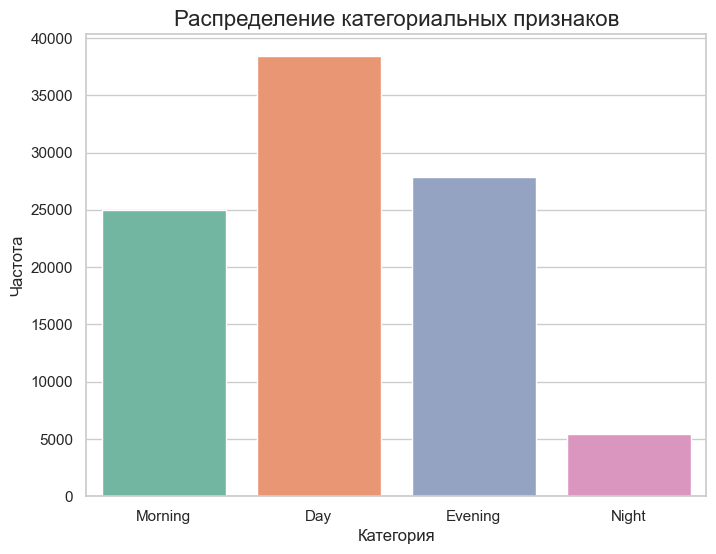

In [71]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8, 6))
# sns.countplot(x='time_of_day', data=r, palette='Set2')

# plt.title('Распределение категориальных признаков', fontsize=16)
# plt.xlabel('Категория', fontsize=12)
# plt.ylabel('Частота', fontsize=12)

# plt.show()


In [72]:
m = merged_df.copy()

In [73]:
merged_df = m.copy()

In [74]:
merged_df['Start District'] = merged_df['Start District'].apply(lambda x: x.lower().replace(' ', '-'))

In [75]:
set(merged_df['Start District'])

{'заречный',
 'ленинский',
 'октябрьский',
 'северо-западный',
 'центральный',
 'юго-восточный'}

In [76]:
merged_df['Start Location'] = merged_df['Start Location'].apply(lambda x: x.lower())
merged_df['End Location'] = merged_df['End Location'].apply(lambda x: x.lower())

In [77]:
set(merged_df['Start Location'])

{'береговая',
 'березовая',
 'буденного',
 'вишневая',
 'вокзальная',
 'восточная',
 'гагарина',
 'гоголя',
 'горького',
 'дачная',
 'дзержинского',
 'дорожная',
 'дружбы',
 'железнодорожная',
 'заводская',
 'западная',
 'заречная',
 'зеленая',
 'калинина',
 'карла маркса',
 'кирова',
 'колхозная',
 'комарова',
 'коммунальная',
 'комсомольская',
 'кооперативная',
 'космонавтов',
 'красная',
 'красноармейская',
 'крупской',
 'куйбышева',
 'ленина',
 'лермонтова',
 'лесная',
 'ломоносова',
 'луговая',
 'майская',
 'матросова',
 'маяковского',
 'мира',
 'мичурина',
 'молодежная',
 'московская',
 'набережная',
 'нагорная',
 'некрасова',
 'новая',
 'овражная',
 'озерная',
 'октябрьская',
 'парковая',
 'партизанская',
 'первомайская',
 'пионерская',
 'победы',
 'подгорная',
 'полевая',
 'почтовая',
 'пролетарская',
 'пушкина',
 'рабочая',
 'речная',
 'рябиновая',
 'садовая',
 'свердлова',
 'свободы',
 'северная',
 'сиреневая',
 'советская',
 'совхозная',
 'солнечная',
 'сосновая',
 'спортивн

In [78]:
merged_df['Start Location'] = merged_df['Start Location'].apply(lambda x: x.lower().replace('ул.', '').replace('ул ', '').strip())
merged_df['End Location'] = merged_df['End Location'].apply(lambda x: x.lower().replace('ул.', '').replace('ул ', '').strip())

In [79]:
len(set(merged_df['Start Location']))

91

In [80]:
len(set(merged_df['End Location']))

91

In [81]:
grouped_streets_by_district = merged_df.groupby('Start District')['Start Location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)

In [82]:
grouped_streets_by_district.sort_values(by='1', ascending=False)

,Start Location,1
Start District,,
центральный,"[труда, пролетарская, зеленая, энтузиастов, пу...",30
юго-восточный,"[шевченко, лесная, коммунальная, центральная, ...",22
ленинский,"[комарова, свободы, подгорная, мичурина, парти...",14
северо-западный,"[первомайская, новая, школьная, рябиновая, раб...",13
заречный,"[чехова, шоссейная, комсомольская, пионерская,...",6
октябрьский,"[буденного, восточная, майская, ломоносова, сп...",6


In [83]:
# reversed_dict = {}
# for k, v in grouped_streets_by_district.drop(columns=['1']).to_dict()['Start Location'].items():
#     for v1 in v:
#         reversed_dict[v1] = k

In [84]:
# merged_df.groupby('Start District')['Start Location'].value_counts()

In [119]:
pd.set_option("display.max_rows", 50)

In [86]:
# start_dist = pd.DataFrame(merged_df[['Start District', 'Start Location']].value_counts()).sort_values(by='count', ascending=False)

In [87]:
# merged_df.groupby('End Location')['End Location'].agg('count').sort_values()[:50]

In [88]:
merged_df['End District'] = merged_df['End District'].apply(lambda x: x.lower().replace(' ', '-'))

In [89]:
merged_df['End Location'] = merged_df['End Location'].apply(lambda x: x.lower().replace('ул.', '').replace('.', '').strip())
merged_df['End Location'] = merged_df['End Location'].apply(lambda x: x.lower().replace('ул ', '').replace('.', '').strip())

In [90]:
len(set(merged_df['End Location']))

91

In [91]:
# a = merged_df[['Start Location', 'End Location', 'Distance']].copy()
# dist = {}

In [92]:
# a['Start Location'] = a['Start Location'].apply(lambda i: reversed_dict[i])
# a['End Location'] = a['End Location'].apply(lambda i: reversed_dict[i])

In [93]:
# a

In [94]:
# for _, i in a.iterrows():
#     if i[0] == i[1]:
#         continue
#     if i[0] + ',' + i[1] in dist.keys():
#         dist[i[0] + ',' + i[1]] = (dist[i[0] + ',' + i[1]] + i[2]) / 2
#     elif i[1] + ',' + i[0] in dist.keys():
#         dist[i[1] + ',' + i[0]] = (dist[i[1] + ',' + i[0]] + i[2]) / 2
#     else:
#         dist[i[0] + ',' + i[1]] = i[2]

In [95]:
# dist

In [96]:
# g = pd.DataFrame(dist.items())
# g['start'] = g[0].apply(lambda x: x.split(',')[0])

In [97]:
# g['end'] = g[0].apply(lambda x: x.split(',')[1])

In [98]:
# g = g.drop(columns=[0])

In [99]:
# g

In [100]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Создадим график для Start Location, End Location и Distance
# plt.figure(figsize=(12, 8))

# # Создадим scatter plot
# sns.scatterplot(data=g, x='start', y='end', size=1, hue=1, palette='viridis', sizes=(20, 200))

# # Настроим внешний вид графика
# plt.title('Start Location vs End Location with Distance', fontsize=16)
# plt.xlabel('Start Location', fontsize=12)
# plt.ylabel('End Location', fontsize=12)
# plt.xticks(rotation=90)  # Повернем метки по оси X
# plt.legend(title='Distance', bbox_to_anchor=(1.05, 1), loc='upper left')  # Легенда с размерами

# # Показать график
# plt.tight_layout()
# plt.show()


In [101]:
# grouped_streets_by_district = merged_df.groupby('Start District')['Start Location'].unique().to_frame()
# grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
# grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)

In [102]:
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt

# G = nx.Graph()

# # Добавляем ребра с весами
# for _, row in g.iterrows():
#     start = row['start']
#     end = row['end']
#     distance = row[1]
#     G.add_edge(start, end, weight=distance)

# # Визуализация: отрисуем упрощённый граф с весами
# plt.figure(figsize=(16, 12))

# # Используем kamada_kawai_layout для более аккуратного расположения вершин
# pos = nx.kamada_kawai_layout(G)

# edges = G.edges(data=True)
# weights = [data['weight'] / 1000 for _, _, data in edges]  # нормализуем веса для толщины линий

# # Рисуем вершины и рёбра
# nx.draw(G, pos, node_color='skyblue', edge_color=weights, with_labels=True, width=weights, font_size=20)

# plt.title("Взвешенный граф перемещений по улицам", fontsize=16)
# plt.axis('off')
# plt.tight_layout()
# plt.show()

In [125]:
merged_df['weekday'] = merged_df['Start Date'].dt.weekday
merged_df['Start Month'] = merged_df['Start Date'].apply(lambda x: x.month)
merged_df['End Month'] = merged_df['End Date'].dt.month
seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}
merged_df['Start Season'] = merged_df['Start Month'].map(seasons)
merged_df['End Season'] = merged_df['End Month'].map(seasons)
merged_df['Time start'] = merged_df['Start Date'].dt.time
merged_df['Time end'] = merged_df['End Date'].dt.time
merged_df['Trip Duration'] = (merged_df['End Date'] - merged_df['Start Date']).dt.total_seconds() / 60
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6

merged_df['Start Hour'] = merged_df['Start Date'].dt.hour
merged_df['Rate per Minute'] = merged_df.apply(lambda row: get_rate(row['weekday'], row['Start Hour']), axis=1)
merged_df['Trip Cost'] = merged_df['Trip Duration'] * merged_df['Rate per Minute']

In [126]:
m = merged_df.copy()

In [127]:
merged_df['DateOnly'] = merged_df['Datetime'].dt.date

# Теперь можно сгруппировать по дате
gbd = merged_df.groupby('DateOnly')

list_data = []
for date, group in gbd:
    list_data.append([date, group])

In [128]:
list_data

[[datetime.date(2023, 4, 22),
           Id          Start Date            End Date Start Location  \
  0    100340 2023-04-22 09:01:03 2023-04-22 09:24:45       шевченко   
  1    100341 2023-04-22 09:01:07 2023-04-22 09:29:32         чехова   
  2    100342 2023-04-22 09:04:27 2023-04-22 09:42:46      буденного   
  3    100343 2023-04-22 09:06:34 2023-04-22 09:38:23          труда   
  4    100344 2023-04-22 09:09:27 2023-04-22 09:40:07   первомайская   
  ..      ...                 ...                 ...            ...   
  942  101280 2023-04-22 23:26:11 2023-04-22 23:42:17       овражная   
  943  101281 2023-04-22 23:26:32 2023-04-22 23:46:23    центральная   
  944  101282 2023-04-22 23:27:42 2023-04-23 00:06:14       трудовая   
  945  101284 2023-04-22 23:29:18 2023-04-22 23:50:48       суворова   
  946  101285 2023-04-22 23:29:28 2023-04-22 23:44:49       дорожная   
  
        Start District End Location     End District  Distance  Promo      Days  \
  0      юго-восточн

In [130]:
average_samokat = []
for i in list_data:
    da = [i[0]]
    datafr = i[1]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = first.merge(second, on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat.append(da)

def union_all_data(x):
    h = x[0]
    for k in range(len(x)):
        h = pd.concat([h, x[k]])
    return h

all_trafic = union_all_data(list(map(lambda x: x[1], average_samokat)))
all_trafic = all_trafic.groupby('Start Location')[['inter', 'leave', 'turn_per_day']].agg('sum').sort_values(by='turn_per_day', ascending=False)

In [149]:
sum(all_trafic['turn_per_day'])

195291

In [150]:
len(merged_df)

96751

In [158]:
list_data[0][1]['weekday']

0      5
1      5
2      5
3      5
4      5
      ..
942    5
943    5
944    5
945    5
946    5
Name: weekday, Length: 947, dtype: int32

In [208]:
from tqdm import tqdm

weekdays = {}

# tqdm добавляет прогресс-бар к итерации
for i in tqdm(list_data, desc="Обработка данных по дням недели"):
    f = dict(tuple(i[1].groupby('weekday')))
    ind = list(set(f.keys()))
    for k in ind:
        if isinstance(weekdays.get(k, 0), int):
            weekdays[k] = f[k]
        else:
            weekdays[k] = pd.concat([weekdays[k], f[k]])

Обработка данных по дням недели: 100%|██████████████████████████████████████████████| 102/102 [00:00<00:00, 208.62it/s]


In [211]:
weekdays

{5:            Id          Start Date            End Date Start Location  \
 0      100340 2023-04-22 09:01:03 2023-04-22 09:24:45       шевченко   
 1      100341 2023-04-22 09:01:07 2023-04-22 09:29:32         чехова   
 2      100342 2023-04-22 09:04:27 2023-04-22 09:42:46      буденного   
 3      100343 2023-04-22 09:06:34 2023-04-22 09:38:23          труда   
 4      100344 2023-04-22 09:09:27 2023-04-22 09:40:07   первомайская   
 ...       ...                 ...                 ...            ...   
 94458  195402 2023-07-29 23:54:12 2023-07-30 00:27:08         дачная   
 94459  195403 2023-07-29 23:55:03 2023-07-30 00:18:58       дорожная   
 94460  195404 2023-07-29 23:55:13 2023-07-30 00:37:01   пролетарская   
 94461  195405 2023-07-29 23:55:21 2023-07-30 00:34:15        луговая   
 94462  195406 2023-07-29 23:58:31 2023-07-30 00:26:31      советская   
 
         Start District End Location     End District  Distance  Promo  \
 0        юго-восточный      майская      окт

In [212]:
average_samokat_to_weekdays = []
for i in weekdays.keys():
    da = [i]
    datafr = weekdays[i]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = first.merge(second, on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat_to_weekdays.append(da)

In [213]:
average_samokat_to_weekdays

[[5,
                  inter  leave  turn_per_day
  Start Location                            
  майская           469    391           860
  ломоносова        430    430           860
  буденного         423    417           840
  спортивная        398    430           828
  восточная         433    385           818
  ...               ...    ...           ...
  горького          148    131           279
  свердлова         141    133           274
  советская         121    152           273
  кооперативная     121    150           271
  крупской          124    138           262
  
  [91 rows x 3 columns]],
 [6,
                   inter  leave  turn_per_day
  Start Location                             
  спортивная         443    418           861
  ломоносова         447    413           860
  буденного          422    424           846
  луговая            462    374           836
  майская            404    407           811
  ...                ...    ...           ...
  пушкин

### Нулевая: Стоит ли закрывать некоторые точки? 
### Альтернативная: Не стоит закрывать никакие точки.

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


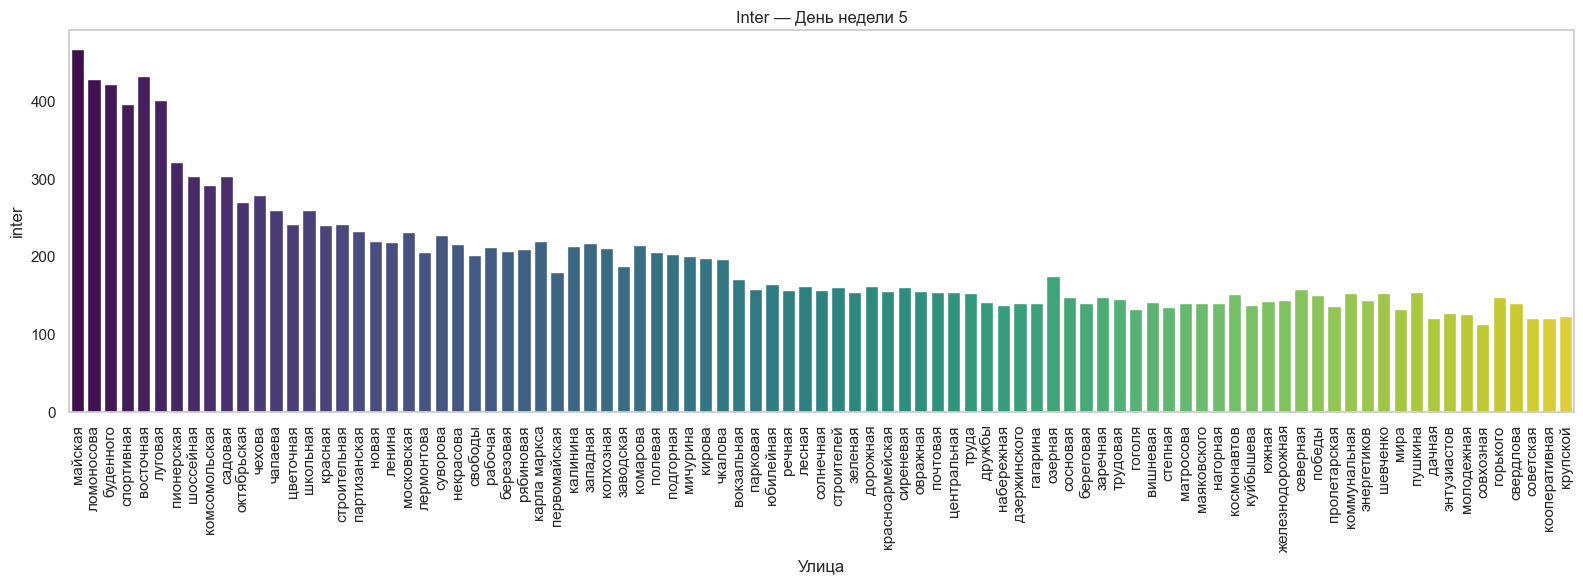

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


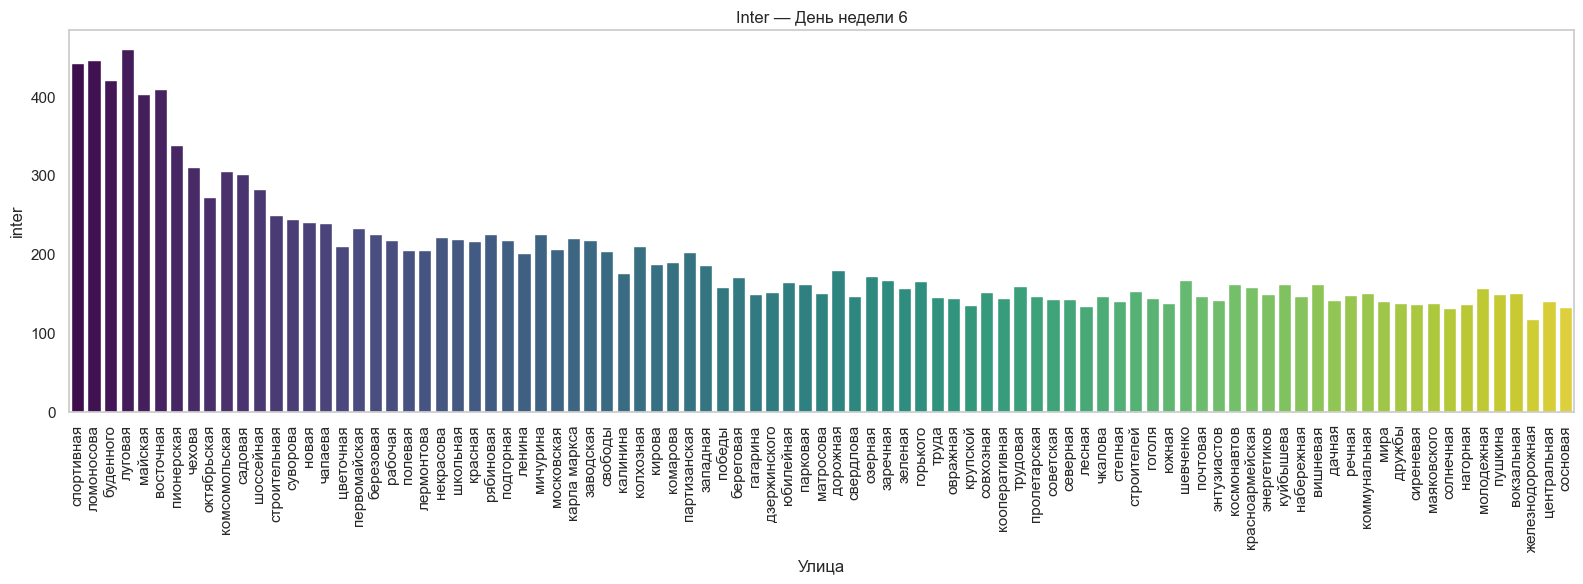

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


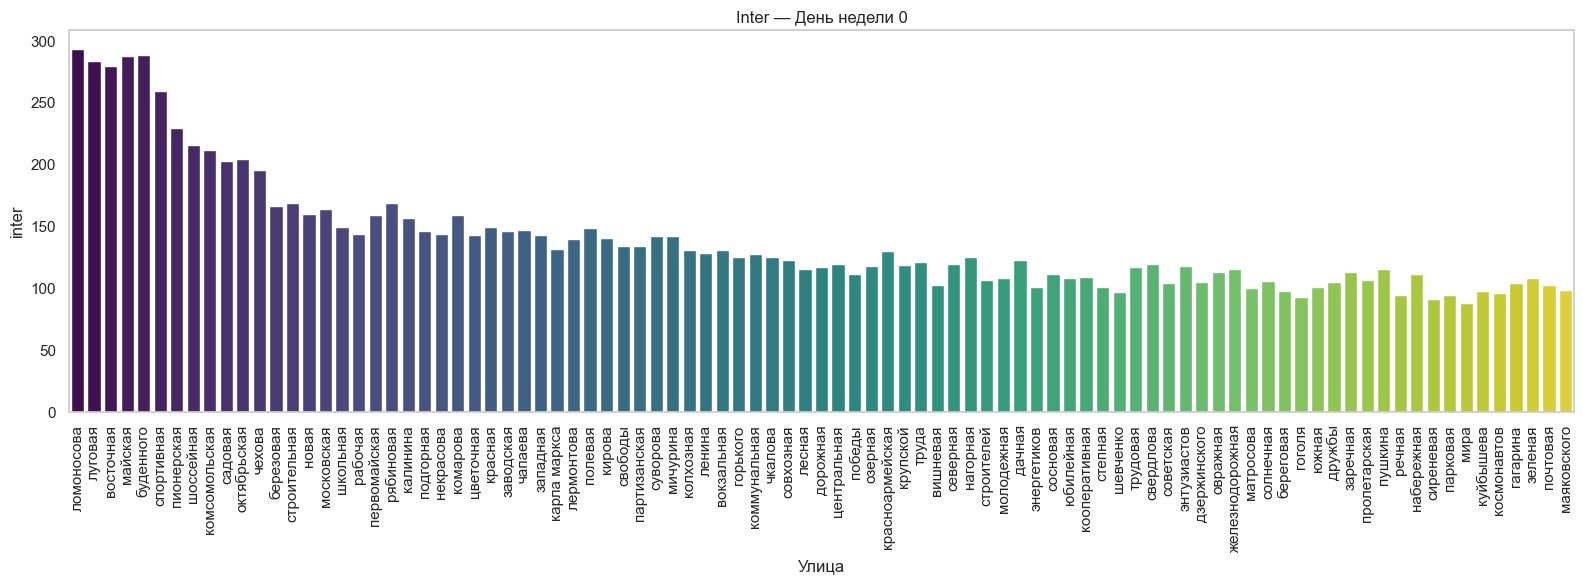

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


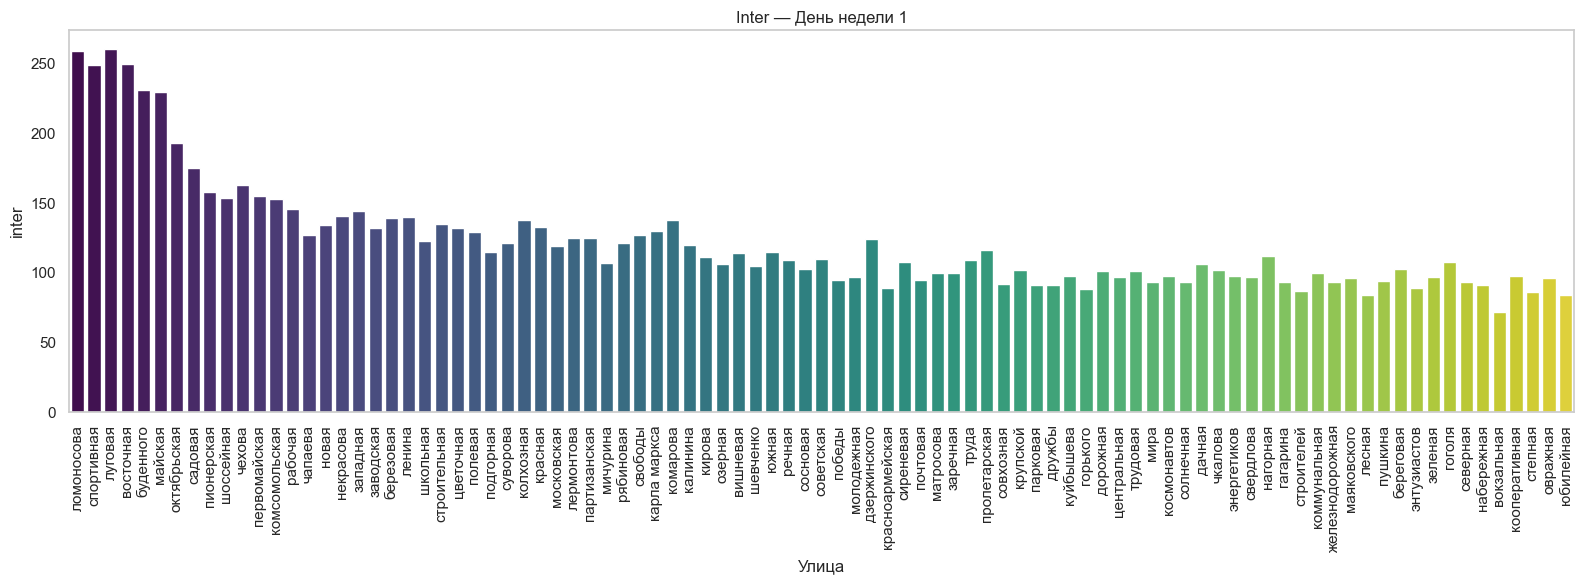

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


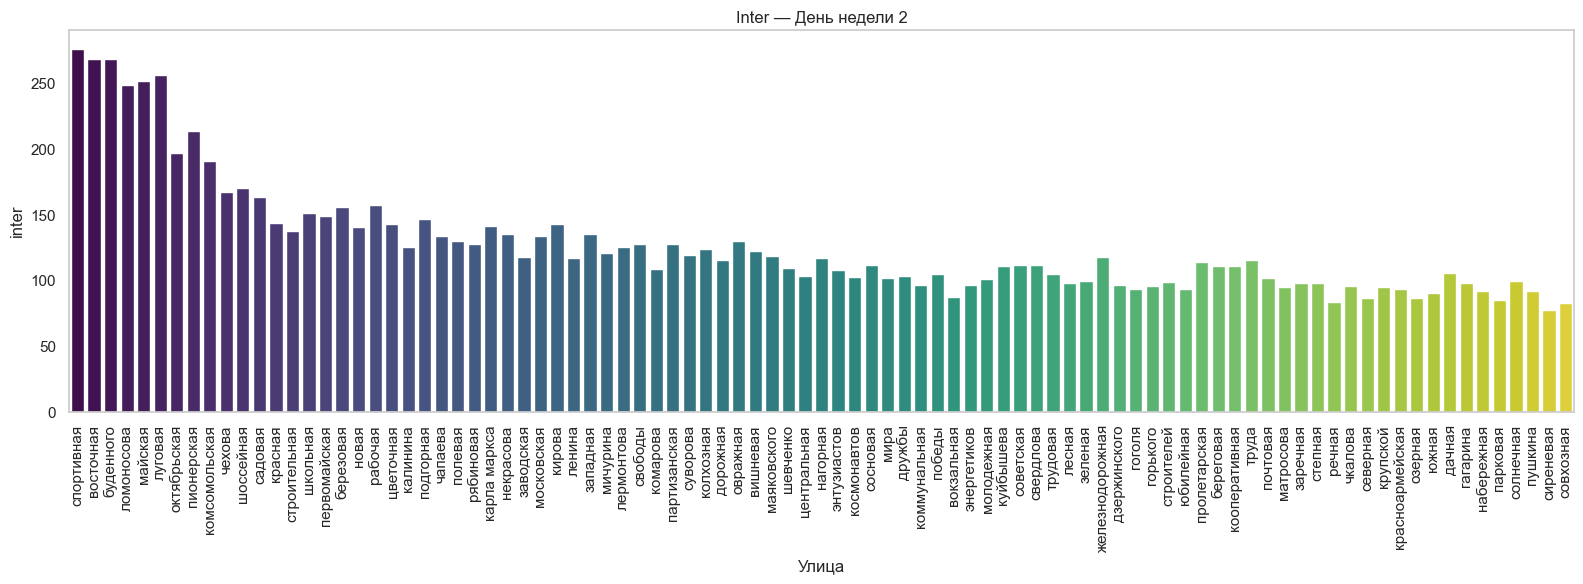

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


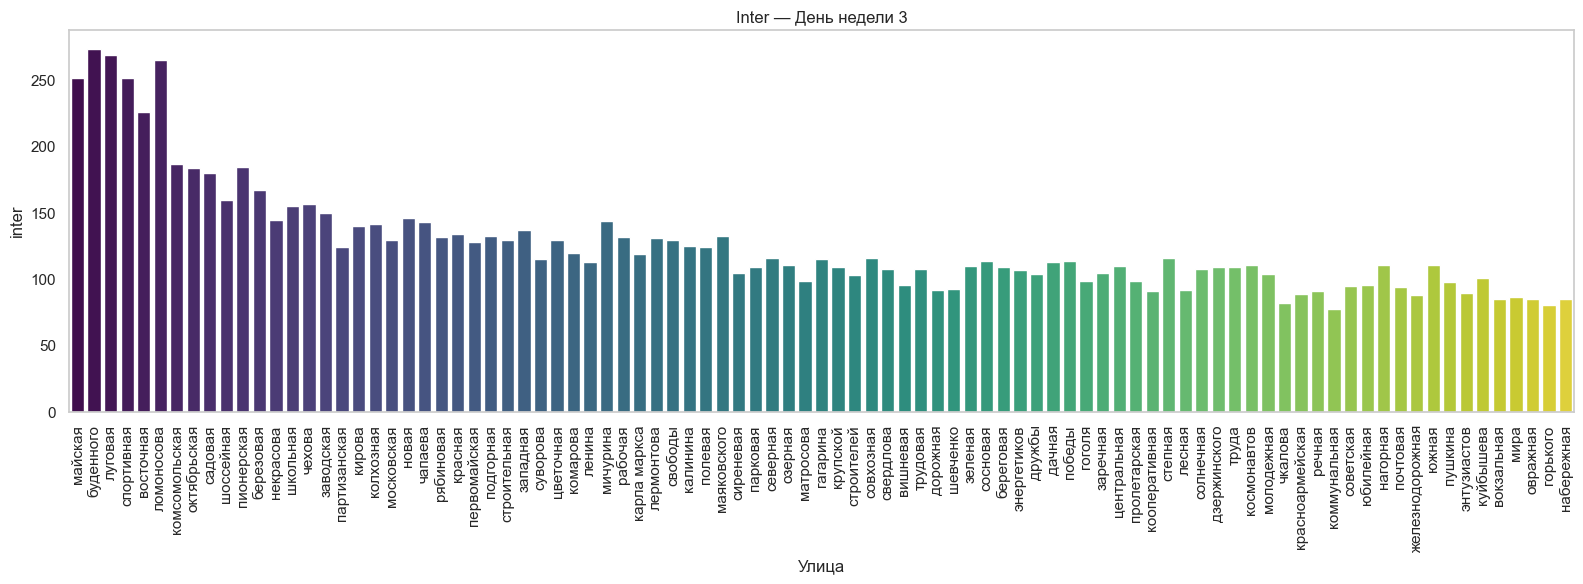

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


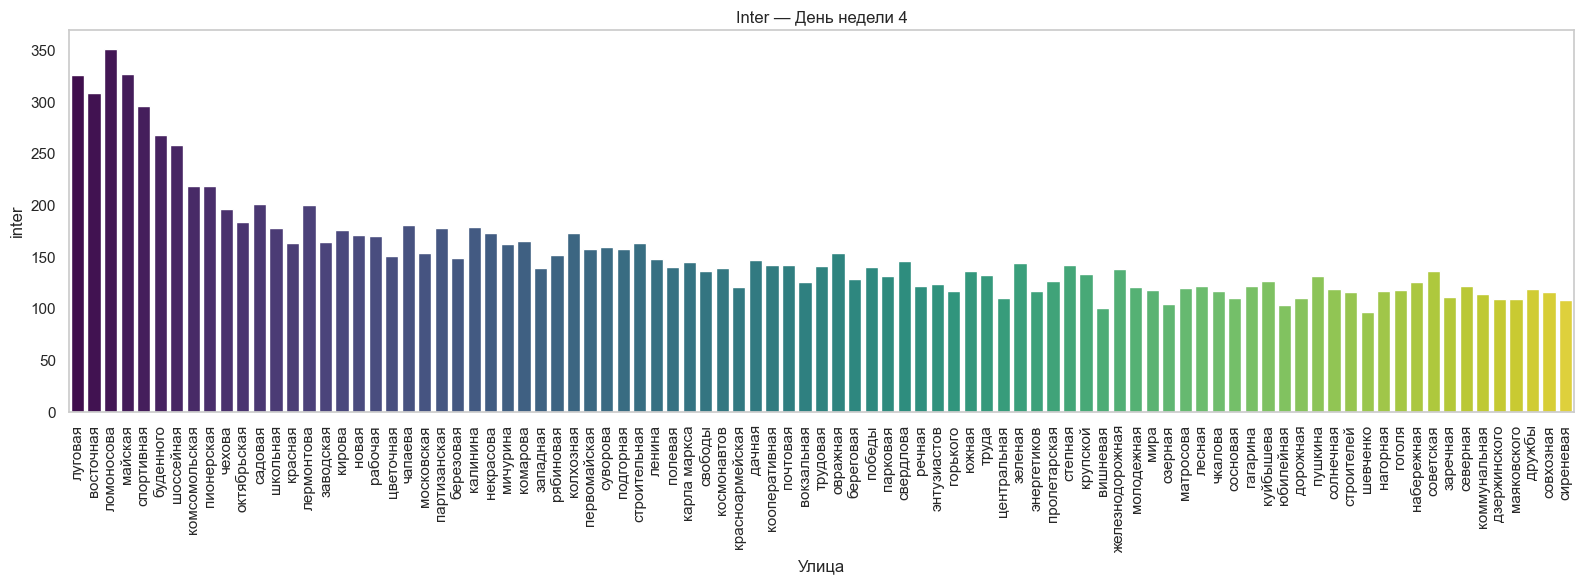

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


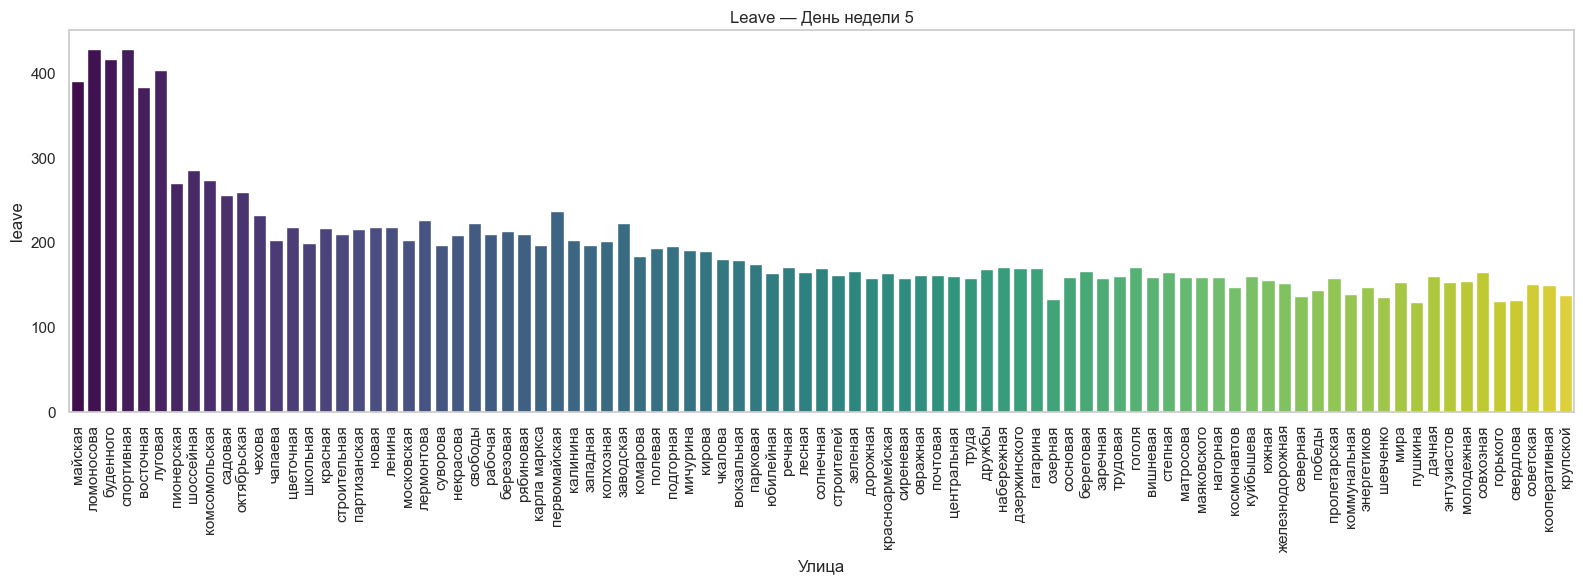

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


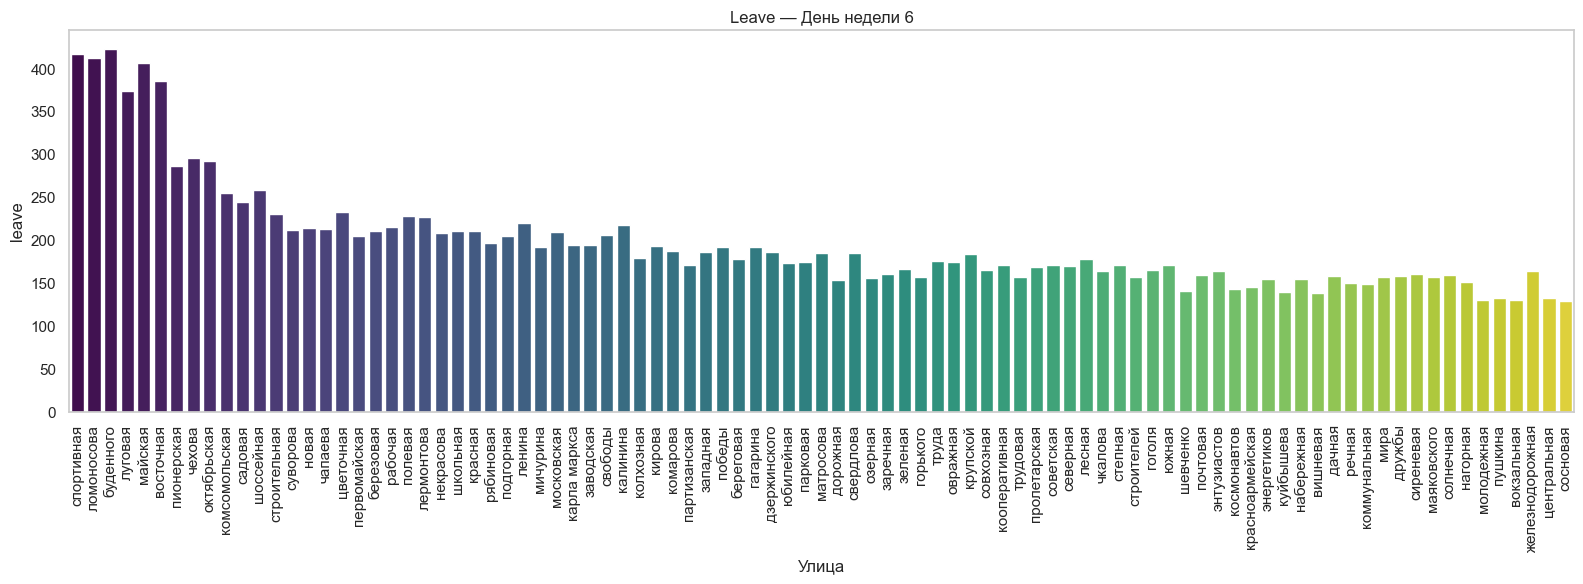

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


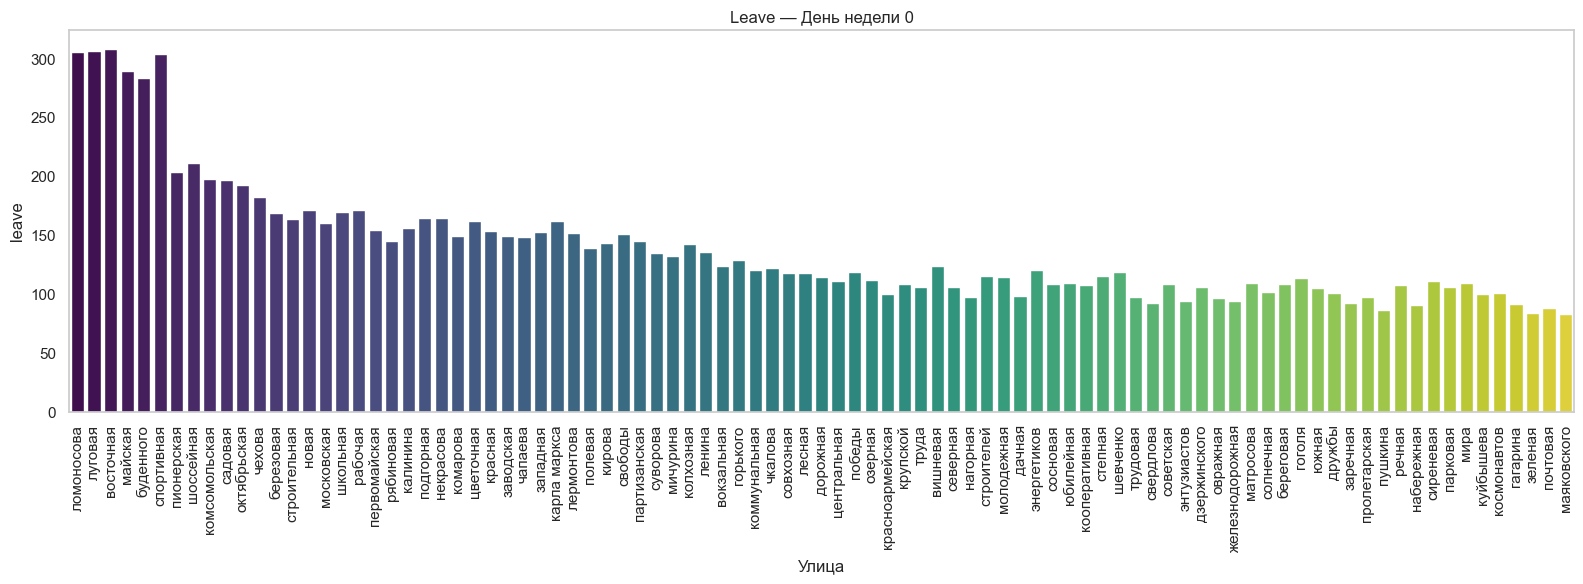

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


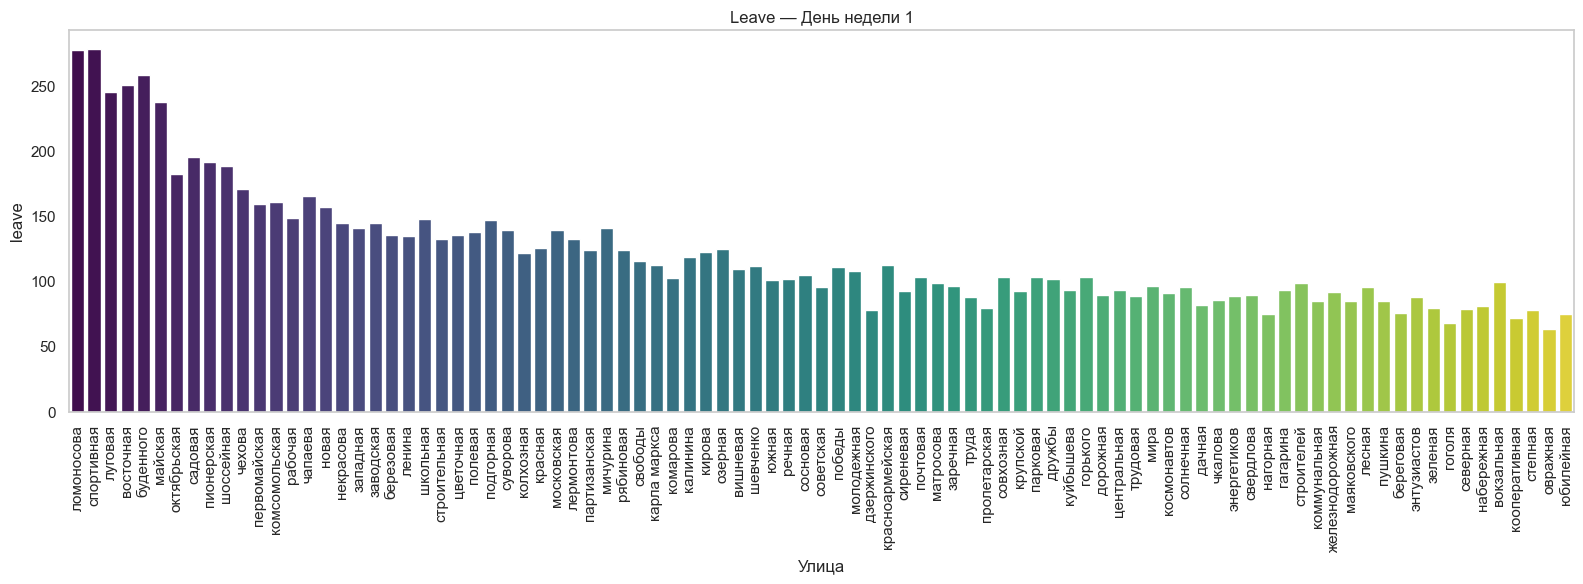

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


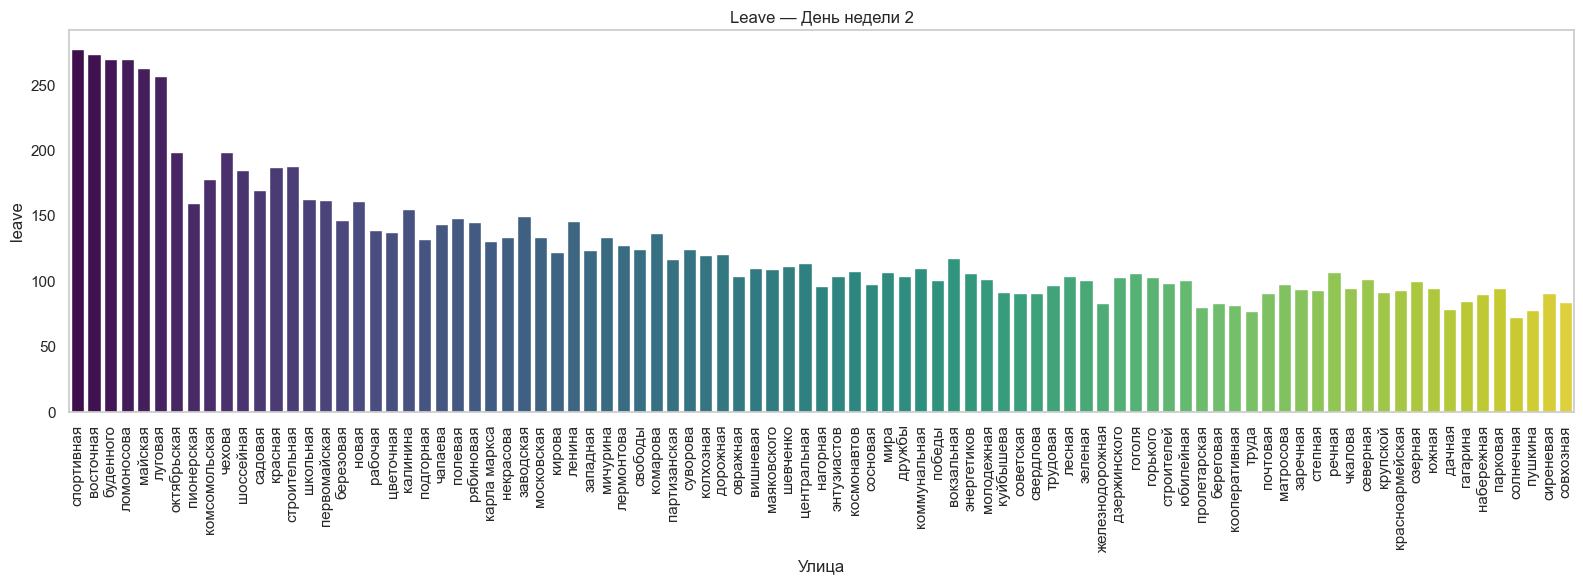

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


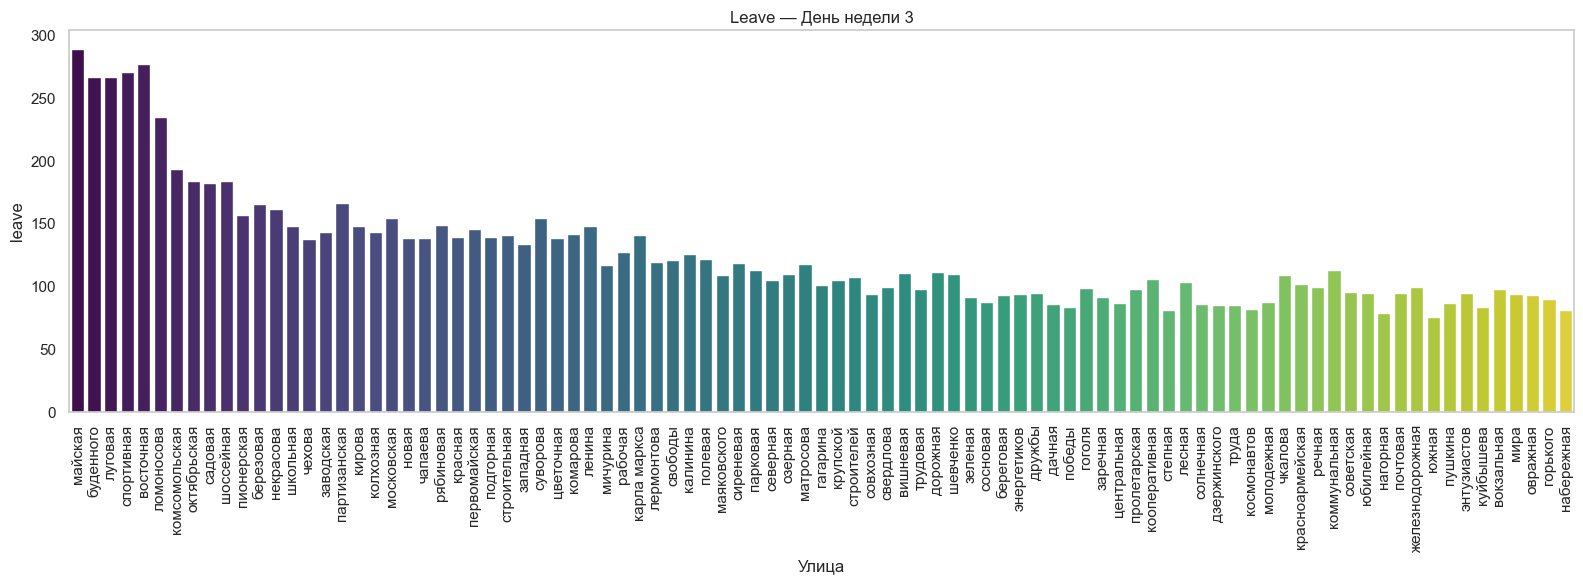

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


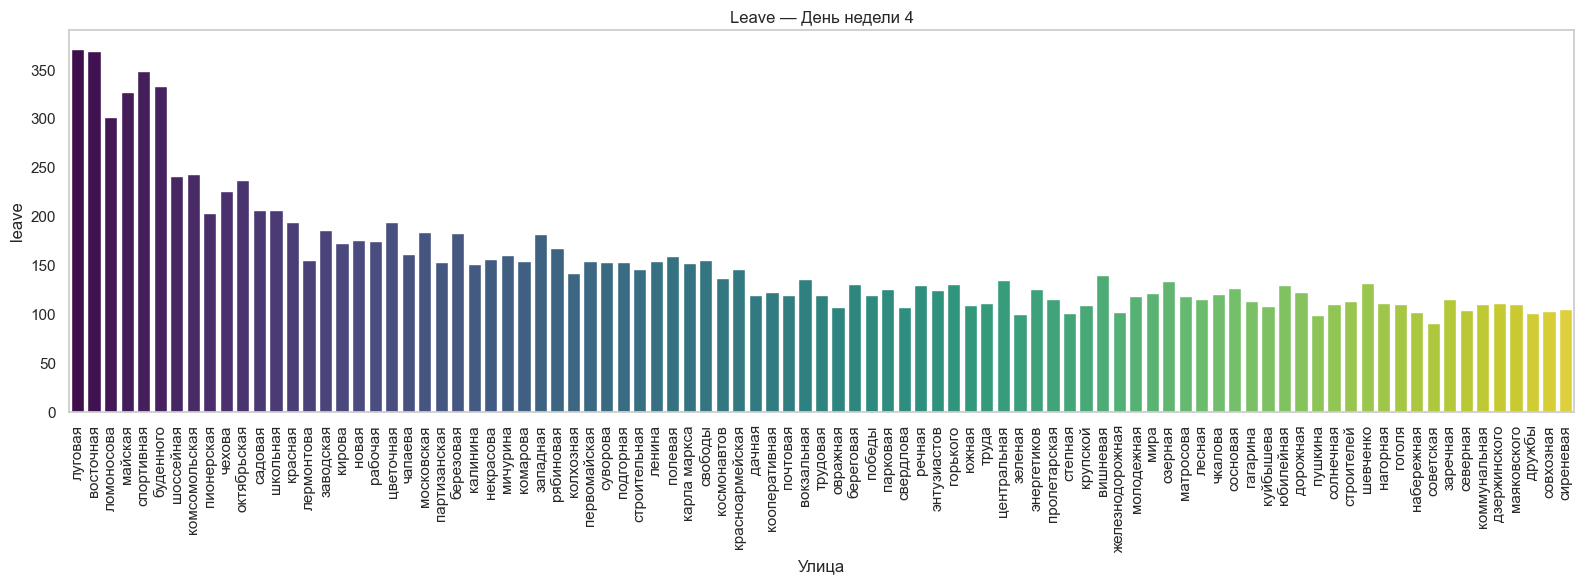

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


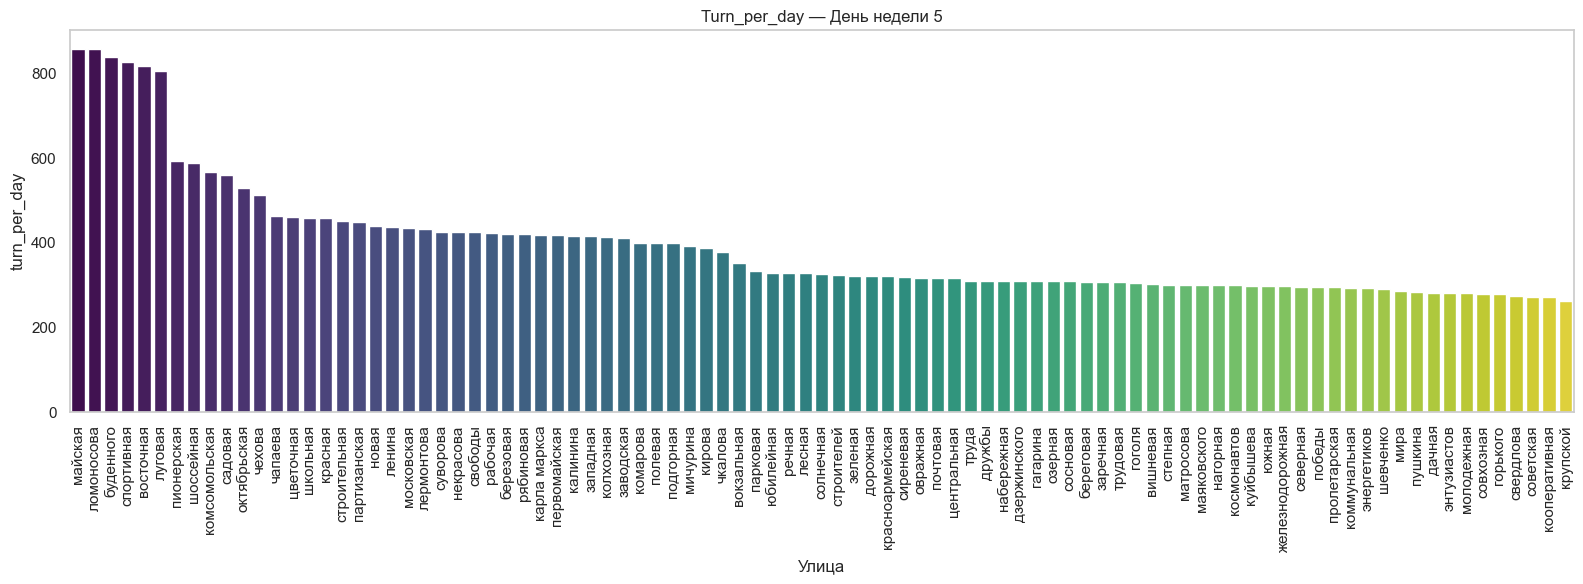

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


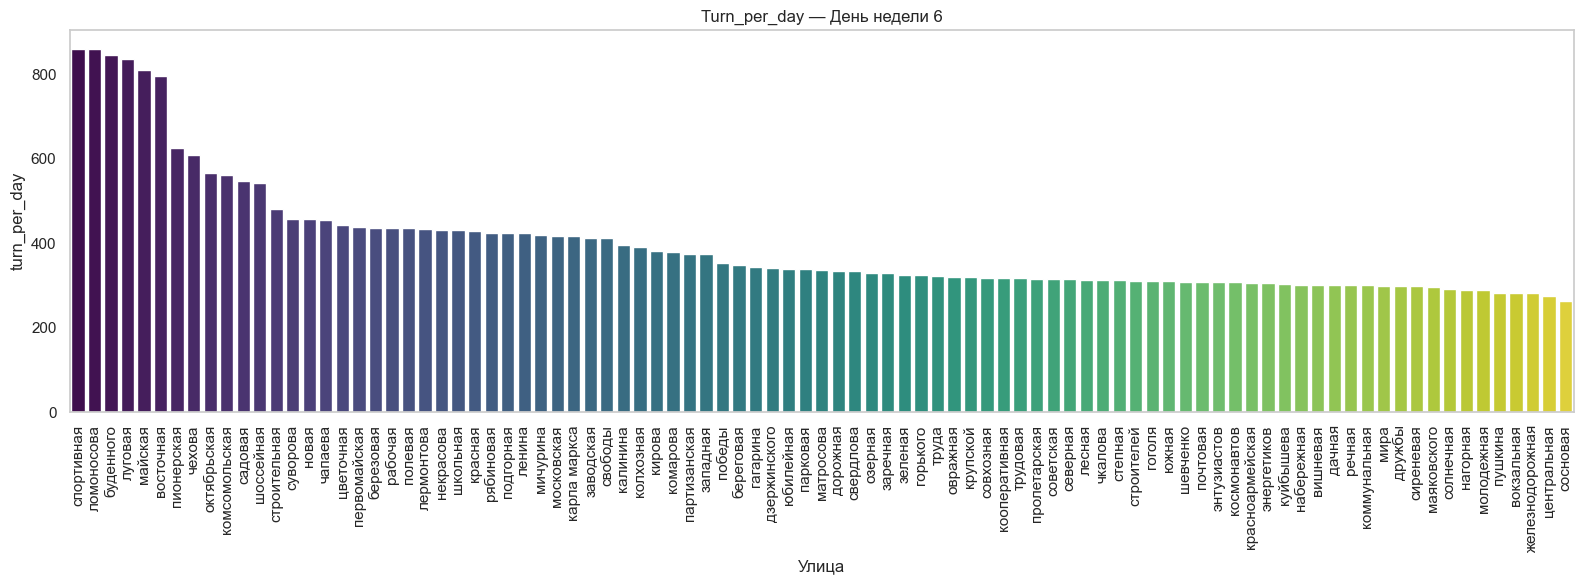

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


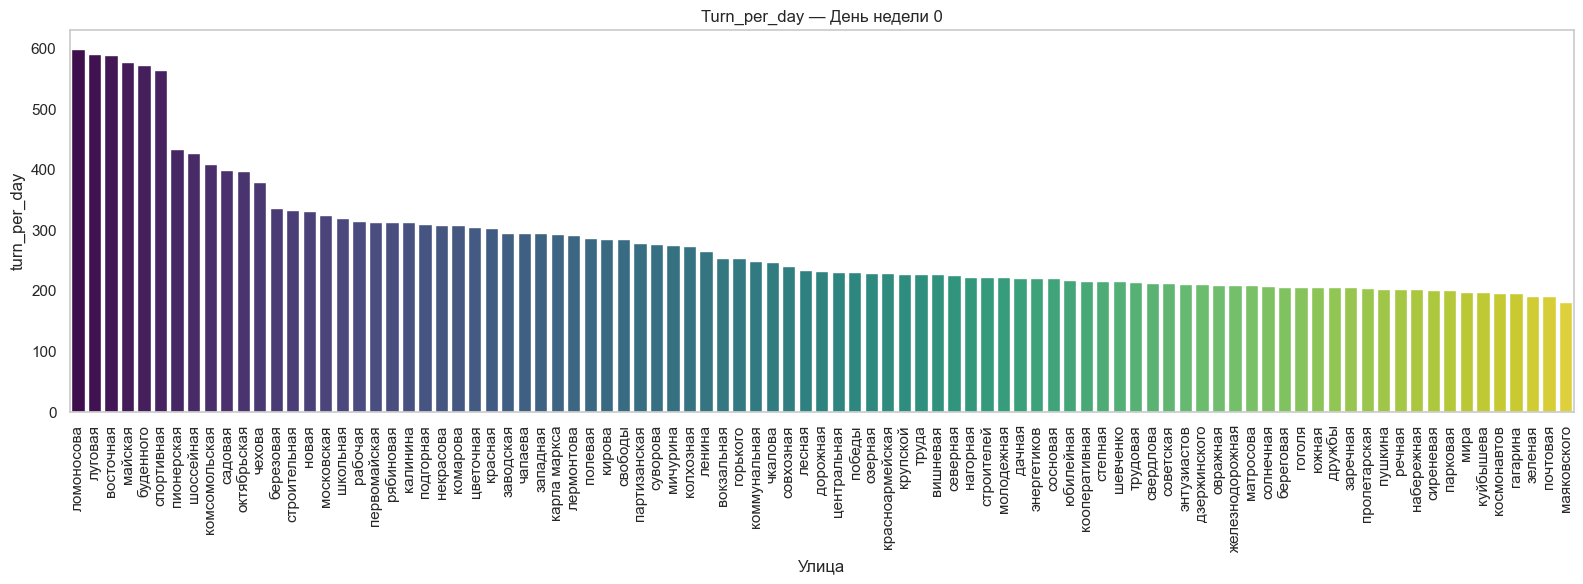

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


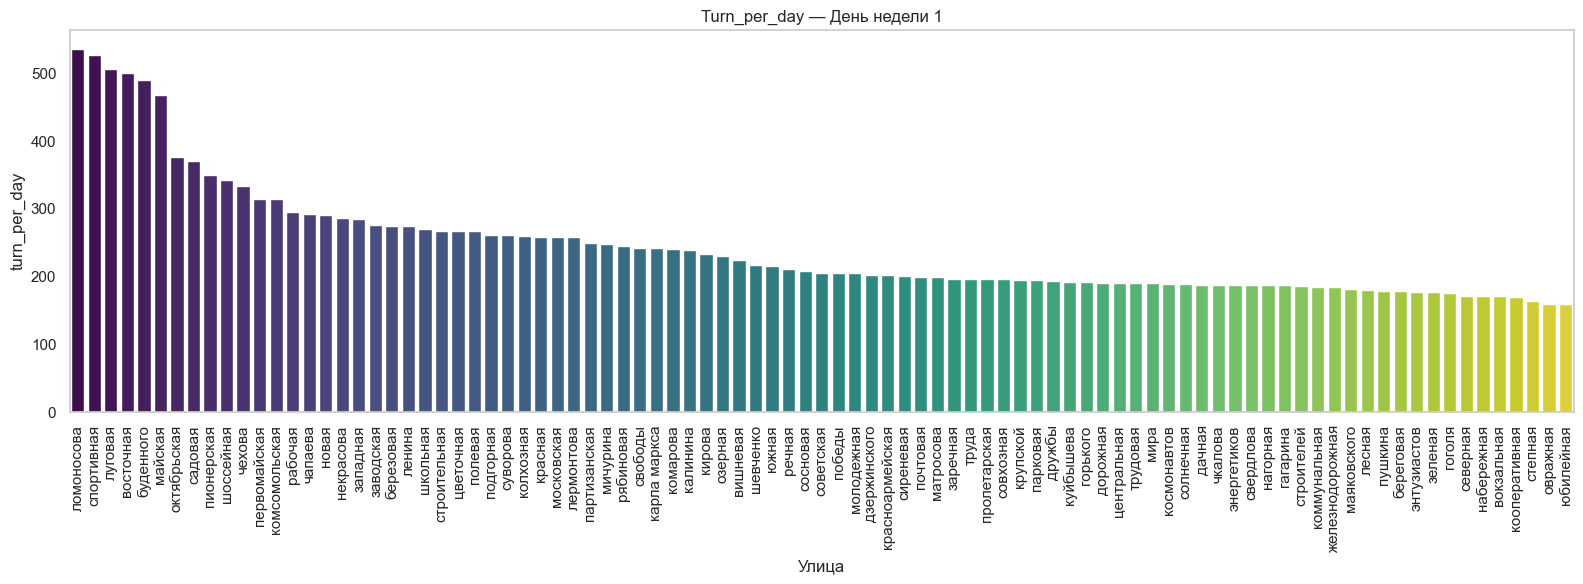

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


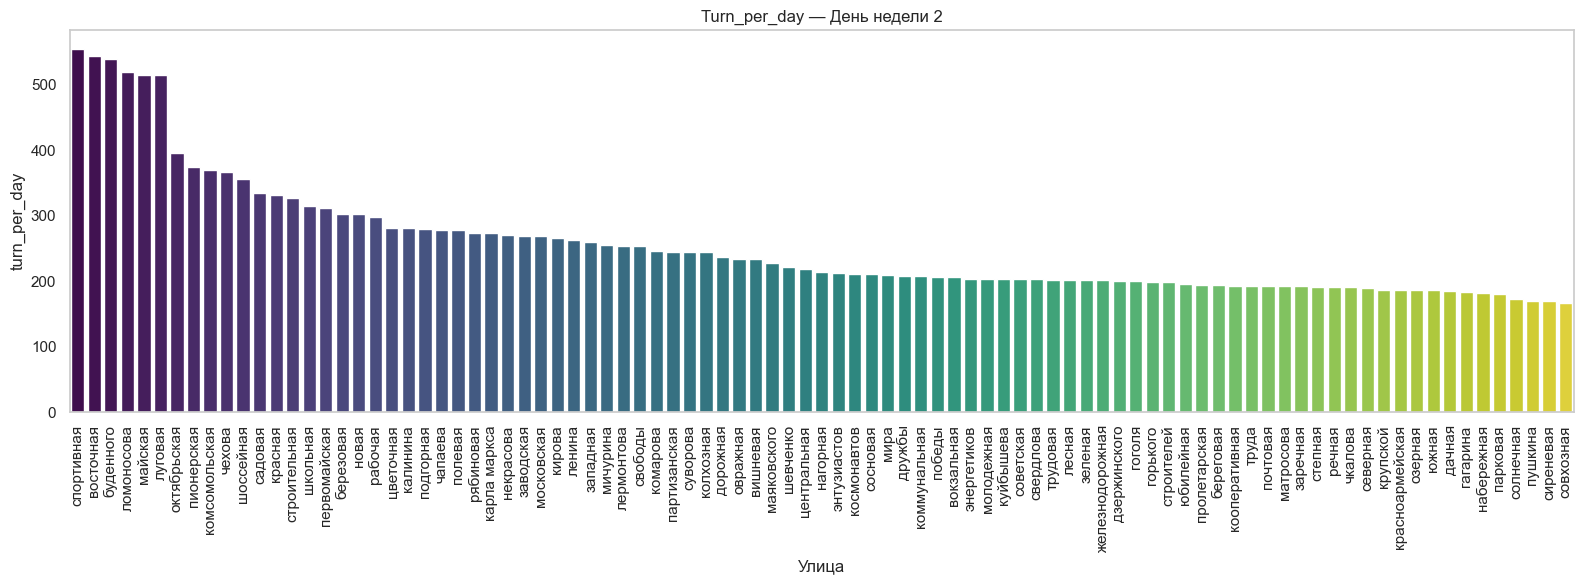

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


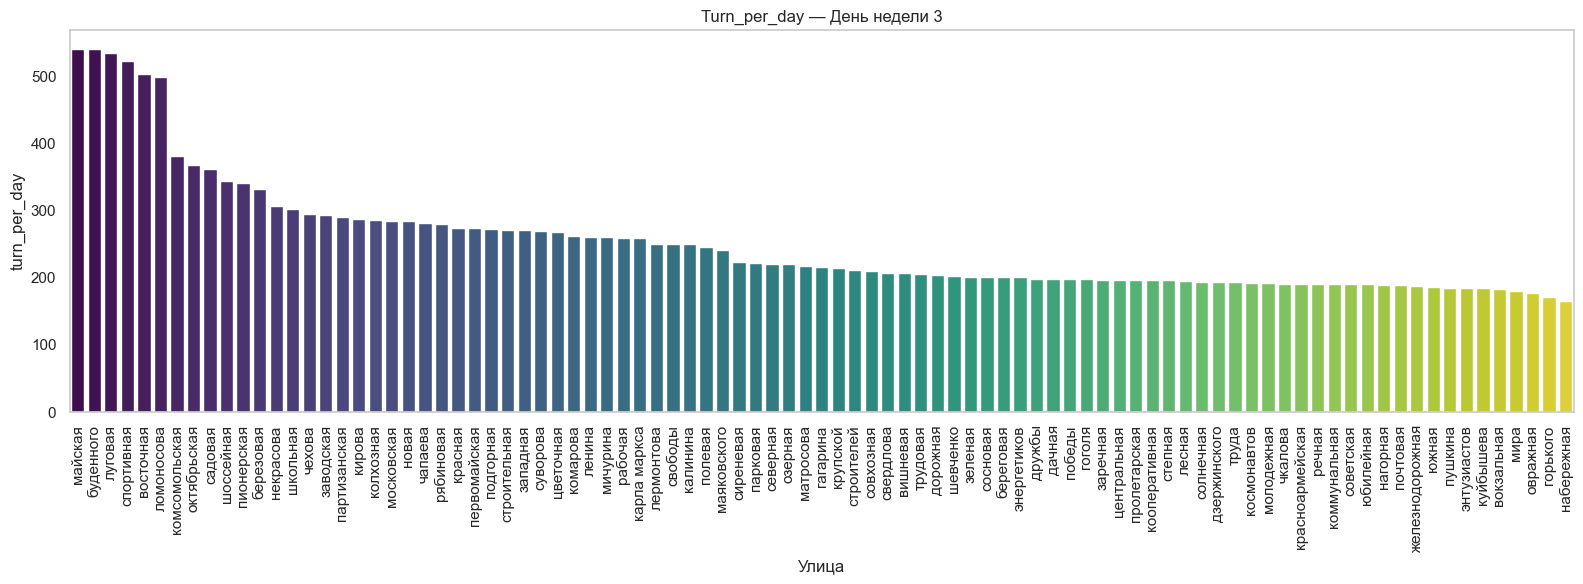

C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\3357102610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=streets, y=values, palette='viridis')


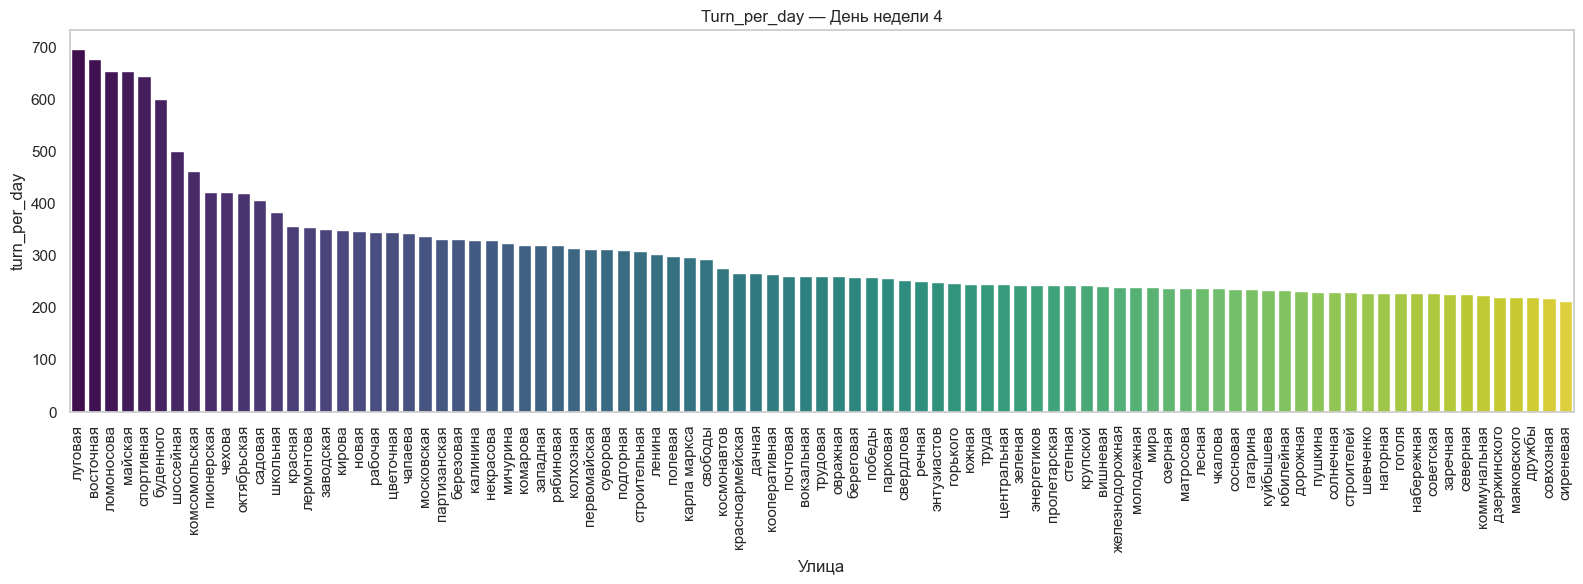

In [217]:
import matplotlib.pyplot as plt
import seaborn as sns

# Пусть data — это твой список из [день, DataFrame]
# Метрики
metrics = ['inter', 'leave', 'turn_per_day']

# Для каждой метрики
for metric in metrics:
    # Для каждого дня недели
    for weekday, df in average_samokat_to_weekdays:
        plt.figure(figsize=(16, 6))
        
        # Берем значения по метрике и улицам
        values = df[metric]
        streets = df.index.tolist()
        
        # Строим гистограмму
        sns.barplot(x=streets, y=values, palette='viridis')

        plt.title(f'{metric.capitalize()} — День недели {weekday}')
        plt.xlabel('Улица')
        plt.ylabel(metric)
        plt.xticks(rotation=90)  # Повернуть подписи улиц
        plt.grid(axis='y')
        plt.tight_layout()
        plt.show()


Вывод: не стоит закрывать ни одной точки, потому что по убы

In [132]:
# reversed_dict = {}
# for k, v in grouped_streets_by_district.drop(columns=['1']).to_dict()['Start Location'].items():
#     for v1 in v:
#         reversed_dict[v1] = k

# all_trafic['district'] = all_trafic.index
# all_trafic['district'] = all_trafic['district'].apply(lambda x: reversed_dict[x])

In [133]:
# reversed_dict

In [134]:
# all_trafic

In [135]:
# all_trafic = all_trafic.groupby('district')[['inter', 'leave', 'turn_per_day']].agg('sum').sort_values(by='turn_per_day', ascending=False)

In [136]:
# merged_df.groupby('Start District')['Promo'].agg('sum').to_frame().sort_values(by='Promo', ascending=False)

In [137]:
# testing = merged_df.copy()

In [138]:
# testing = testing[testing['Start District'] == testing['End District']].groupby('Start District')['End District'].agg('count').to_frame().sort_values(by='End District', ascending=False)

In [139]:
# all_trafic

In [140]:
# testing['district'] = testing.index
# all_trafic['district'] = all_trafic.index

In [141]:
# testing.sort_values(by='End District', ascending=False)

In [142]:
# testing = testing.reset_index()
# all_trafic = all_trafic.reset_index()

# # Теперь можно выполнить merge
# t = testing.merge(all_trafic, on='district')

In [143]:
# all_trafic.index.name = 'Start District'

In [144]:
# t.drop(columns=['index', 'Start District_x', 'Start District_y'])

In [145]:
# merged_df.columns

In [146]:
# merged_df.columns

In [147]:
# all_trafic

In [242]:
(
    weekdays[0]
    .groupby('Promo')
    .apply(lambda x: x)
    .loc[1]
    .groupby('Start Location')['Start Location']
    .agg('count')
    .sort_values(ascending=False)  # <-- сортировка по убыванию
    .to_frame(name='count')        # <-- имя колонки для наглядности
)


C:\Users\SIDov\AppData\Local\Temp\ipykernel_11448\2972001240.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x)


,count
Start Location,
ломоносова,52
спортивная,50
буденного,48
луговая,44
пионерская,39
...,...
пролетарская,8
маяковского,6
мира,5
